# Cuaderno 04: Modelo de Clustering - Descubrimiento de Fenotipos Clínicos en UCI

**Objetivo:** Aplicar técnicas de aprendizaje automático **no supervisado** para segmentar a los pacientes de UCI en grupos ("fenotipos clínicos") con características similares en cuanto a comorbilidades, constantes vitales de ingreso, edad, diagnóstico de admisión y servicio clínico. A diferencia de los Cuadernos 02 y 03, este modelo no tiene variable objetivo, el propósito es puramente exploratorio, para descubrir si existen patrones naturales de agrupación clínicamente relevantes en los datos.

`DiedInHospital` y `DischargeDayNumber` **no participan** en el proceso de clustering (no se usan para entrenar ni para determinar el número de clústeres). Se reservan exclusivamente para una validación externa posterior, una vez obtenidos los clústeres de forma no supervisada, se comprueba si tienen sentido clínico observando su tasa real de mortalidad.

**Estructura de este cuaderno:** se presenta primero un modelo inicial (Sección 1-9), construido sobre un rango de búsqueda moderado y con `DiagnosisAdmission` incluida. Ese modelo inicial deja dos preguntas metodológicas abiertas (Sección 10), que se investigan mediante un conjunto de pruebas adicionales resumidas en la Sección 11 (sin reproducir aquí cada pruebal). Esas pruebas motivan un modelo final (Sección 12), que se compara con el inicial en la Sección 13.

---

## 1. Importación de Librerías
Carga de las herramientas necesarias para el preprocesado, la reducción de dimensionalidad y los algoritmos de clustering.

In [1]:
# Importación de librerías base
import pandas as pd
import numpy as np
import os
import warnings

# Preprocesado y reducción de dimensionalidad
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

# Algoritmos de clustering
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# Métricas de evaluación de clustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 2. Carga de Datos y Selección de Variables de Entrada

Se carga el mismo Gold Dataset generado en el Cuaderno 01, ya limpio e imputado (162.009 registros, sin nulos). Al tratarse de un modelo no supervisado, **no se realiza partición train/test**, el objetivo es descubrir la estructura de agrupación presente en la totalidad de los pacientes, no generalizar una predicción a datos no vistos.

In [2]:
print("Cargando el Gold Dataset...")
ruta_parquet = 'datos_procesados/uci_gold_dataset.parquet'

df_uci = pd.read_parquet(ruta_parquet)
print(f"Dimensiones iniciales: {df_uci.shape}\n")

Cargando el Gold Dataset...
Dimensiones iniciales: (162009, 46)



In [3]:
display(df_uci.head())

,Gender,Ethnicity,Age,AdmissionHeight,AdmissionWeight,UnitType,UnitStayType,DiagnosisAdmission,Service,APS,...,PastHistory,Meds,Glucose,Sodium,Creatinine,BUN,Hematocrit,WBC,AdmitHour,DischargeDayNumber
0,Male,Hispanic,54.0,162.6,63.5,CTICU,admit,Unknown,unknown,38.0,...,Unknown/Not Performed,0,174.0,139.0,3.00,30.0,21.6,9.3,Mañana,0
1,Male,Caucasian,69.0,175.0,93.0,SICU,admit,"Renal failure, acute",renal,53.0,...,Performed,0,299.0,134.0,5.04,126.0,30.6,16.5,Noche,0
2,Female,Other/Unknown,72.0,152.4,55.2,Med-Surg ICU,readmit,"Sepsis, other",infectious diseases,56.0,...,Performed,0,41.0,138.0,0.99,19.0,32.6,10.4,Mañana,0
3,Male,Hispanic,66.0,175.3,95.2,Cardiac ICU,admit,"Angina, unstable (angina interferes w/quality ...",cardiovascular,23.0,...,Performed,0,81.0,139.0,1.00,17.0,32.6,10.4,Mañana,0
4,Male,Caucasian,56.0,178.0,86.0,CCU-CTICU,admit,Emphysema/bronchitis,pulmonary,38.0,...,Performed,0,135.0,138.0,0.99,19.0,32.6,10.4,Mañana,0


### 2.2. Selección de Variables de Entrada

El clustering se construye **únicamente** con tres bloques de variables, deliberadamente acotados para que los fenotipos resultantes reflejen el perfil clínico del paciente al ingreso, y no una mezcla con variables de gravedad, tratamiento o resultado que distorsionarían la agrupación:

- **Comorbilidades** (booleanas 0/1): `Diabetes`, `Cirrhosis`, `HepaticFailure`, `MetastaticCancer`, `Leukemia`, `Immunosuppression`, `MI`. Todos los flags de comorbilidad disponibles en el Gold Dataset.
- **Constantes vitales de ingreso y edad**: `HeartRate_Admission`, `RespiratoryRate_Admission`, `MeanBP_Admission`, `Temperature`, `Age`.
- **Categóricas** (se codifican con One-Hot Encoding): `DiagnosisAdmission`, `Service`.

Quedan **explícitamente fuera** del clustering, entre otras, los scores de gravedad (`APS`, `ApacheScore`) y los componentes de la escala de Glasgow (`Eyes`, `Motor`, `Verbal`), por resumir ya de forma agregada el riesgo/pronóstico del paciente; los flags de soporte vital y tratamiento (`Vent`, `Dialysis`, `ActiveTreatment`, `Thrombolytics`, etc.), por ser decisiones clínicas posteriores al ingreso y no un rasgo intrínseco del paciente; y los valores analíticos (`Glucose`, `Sodium`, `Creatinine`, `BUN`, `Hematocrit`, `WBC`), para mantener el fenotipo centrado en el perfil clínico-demográfico de base. `DiedInHospital` y `DischargeDayNumber` se excluyen igualmente, y se reservan aparte para la validación post-hoc (Sección 7).

In [4]:
print("Definiendo los bloques de variables de entrada para el clustering...")

comorbilidades = [
    'Diabetes', 'Cirrhosis', 'HepaticFailure', 'MetastaticCancer',
    'Leukemia', 'Immunosuppression', 'MI'
]
vitales_edad = [
    'HeartRate_Admission', 'RespiratoryRate_Admission', 'MeanBP_Admission',
    'Temperature', 'Age'
]
categoricas = ['DiagnosisAdmission', 'Service']

variables_clustering = comorbilidades + vitales_edad + categoricas

X_cluster_raw = df_uci[variables_clustering].copy()

# Variables reservadas para la validación post-hoc (Sección 7) - NO participan en el clustering
mortalidad_real = df_uci['DiedInHospital'].copy()

print(f"Variables de entrada seleccionadas: {len(variables_clustering)}")
print(f"  - Comorbilidades: {comorbilidades}")
print(f"  - Vitales y edad: {vitales_edad}")
print(f"  - Categóricas (a codificar): {categoricas}")
print(f"\nDimensiones de la matriz de entrada (antes de codificar): {X_cluster_raw.shape}")

nulos = X_cluster_raw.isna().sum()
print(f"\nValores nulos en las variables seleccionadas: {nulos.sum()} (deben ser 0, dataset ya imputado en el Cuaderno 01)")

Definiendo los bloques de variables de entrada para el clustering...
Variables de entrada seleccionadas: 14
  - Comorbilidades: ['Diabetes', 'Cirrhosis', 'HepaticFailure', 'MetastaticCancer', 'Leukemia', 'Immunosuppression', 'MI']
  - Vitales y edad: ['HeartRate_Admission', 'RespiratoryRate_Admission', 'MeanBP_Admission', 'Temperature', 'Age']
  - Categóricas (a codificar): ['DiagnosisAdmission', 'Service']

Dimensiones de la matriz de entrada (antes de codificar): (162009, 14)

Valores nulos en las variables seleccionadas: 0 (deben ser 0, dataset ya imputado en el Cuaderno 01)


## 3. Preprocesado: Codificación, Escalado y PCA

### 3.1. Codificación One-Hot de Variables Categóricas

`DiagnosisAdmission` (70 categorías) y `Service` (18 categorías) se codifican con `OneHotEncoder`. A diferencia de los Cuadernos 02 y 03, aquí no hay partición train/test que obligue a ajustar el encoder solo sobre un subconjunto. Al ser un modelo no supervisado sin evaluación out-of-sample, el encoder se ajusta directamente sobre la totalidad de los datos. Se mantiene `drop='first'` (evita redundancia entre columnas *dummy*) por coherencia con el criterio ya usado en los cuadernos anteriores.

In [5]:
print("Codificando variables categóricas (One-Hot Encoding)...")

encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
cat_encoded = encoder.fit_transform(X_cluster_raw[categoricas])
encoded_cols = encoder.get_feature_names_out(categoricas)

# Matriz final: comorbilidades + vitales/edad + categóricas codificadas
X_cluster = pd.concat([
    X_cluster_raw[comorbilidades + vitales_edad].reset_index(drop=True),
    pd.DataFrame(cat_encoded, columns=encoded_cols)
], axis=1)

print(f"Columnas dummy generadas: {len(encoded_cols)}")
print(f"Dimensiones de la matriz final antes de escalar: {X_cluster.shape}")
display(X_cluster.head())

Codificando variables categóricas (One-Hot Encoding)...
Columnas dummy generadas: 86
Dimensiones de la matriz final antes de escalar: (162009, 98)


,Diabetes,Cirrhosis,HepaticFailure,MetastaticCancer,Leukemia,Immunosuppression,MI,HeartRate_Admission,RespiratoryRate_Admission,MeanBP_Admission,...,Service_musculoskeletal,Service_neurologic,Service_obstetrics/gynecology,Service_oncology,Service_pulmonary,Service_renal,Service_surgery,Service_toxicology,Service_transplant,Service_unknown
0,0,0,0,0,0,0,0,109.0,7.0,62.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,0,0,0,0,0,0,130.0,38.0,144.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0,0,0,0,0,0,0,122.0,24.0,53.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,0,0,0,100.0,8.0,64.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0,0,0,0,118.0,33.0,72.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


### 3.2. Escalado (`StandardScaler`)

K-Means y GMM se basan en distancias (K-Means, distancia euclídea al centroide) o en densidades gaussianas (GMM), por lo que **todas las variables deben pesar en una escala comparable**. Sin escalar, variables como `HeartRate_Admission` (rango ~40-180) dominarían por completo sobre las variables *dummy* (0/1). El `StandardScaler` se ajusta sobre la matriz completa (comorbilidades + vitales/edad + *dummies*).

In [6]:
print("Escalando la matriz de variables (StandardScaler)...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f"Dimensiones tras el escalado: {X_scaled.shape}")
print(f"Media tras escalar (debe ser ~0): {X_scaled.mean():.6f}")
print(f"Desviación típica tras escalar (debe ser ~1): {X_scaled.std():.6f}")

Escalando la matriz de variables (StandardScaler)...
Dimensiones tras el escalado: (162009, 98)
Media tras escalar (debe ser ~0): 0.000000
Desviación típica tras escalar (debe ser ~1): 1.000000


### 3.3. Reducción de Dimensionalidad (PCA)

El One-Hot Encoding de `DiagnosisAdmission` y `Service` introduce una alta dimensionalidad (decenas de columnas *dummy*, la mayoría con varianza baja). Para mitigar este efecto antes de clusterizar se aplica PCA reteniendo el número de componentes principales necesario para explicar el **90% de la varianza acumulada**. El clustering se ejecuta sobre estos componentes, no sobre las variables originales.

In [7]:
print("Aplicando PCA (reteniendo el 90% de la varianza explicada)...")

pca = PCA(n_components=0.90, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

n_componentes = X_pca.shape[1]
varianza_explicada = pca.explained_variance_ratio_.sum()

print(f"Dimensiones originales (tras encoding + escalado): {X_scaled.shape[1]} variables")
print(f"Componentes principales retenidos: {n_componentes}")
print(f"Varianza acumulada explicada: {varianza_explicada:.4f}")

Aplicando PCA (reteniendo el 90% de la varianza explicada)...
Dimensiones originales (tras encoding + escalado): 98 variables
Componentes principales retenidos: 75
Varianza acumulada explicada: 0.9087


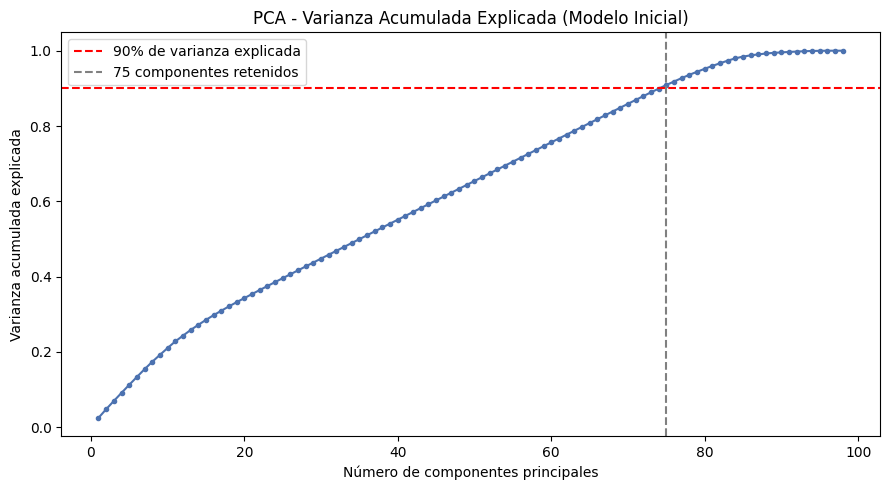

In [8]:
# Visualización de la varianza acumulada explicada por componente
varianza_acumulada_total = np.cumsum(PCA(random_state=RANDOM_STATE).fit(X_scaled).explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(varianza_acumulada_total) + 1), varianza_acumulada_total, marker='.', color='#4C72B0')
ax.axhline(0.90, color='red', linestyle='--', label='90% de varianza explicada')
ax.axvline(n_componentes, color='gray', linestyle='--', label=f'{n_componentes} componentes retenidos')
ax.set_xlabel('Número de componentes principales')
ax.set_ylabel('Varianza acumulada explicada')
ax.set_title('PCA - Varianza Acumulada Explicada (Modelo Inicial)')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Determinación del Número de Clústeres

**Consideración de escalabilidad:** con 162.009 registros, el Clustering Jerárquico queda descartado como algoritmo principal (requeriría una matriz de distancias de ~1.3×10¹⁰ pares, inviable en memoria y tiempo). Por el mismo motivo, el *Silhouette Score* (que también tiene coste O(n²)) no se calcula sobre el dataset completo, sino sobre una **submuestra aleatoria fija de 5.000 pacientes** (`random_state=42`), tanto para K-Means como para GMM. Los modelos en sí (K-Means y GMM) sí se entrenan sobre la totalidad de los 162.009 registros, ya que ambos escalan bien a este volumen.

### 4.1. Submuestra Fija para el Cálculo del Silhouette Score

In [9]:
print("Generando la submuestra fija para el cálculo del Silhouette Score...")

N_MUESTRA_SILHOUETTE = 5000
rng_silhouette = np.random.RandomState(RANDOM_STATE)
idx_muestra_silhouette = rng_silhouette.choice(X_pca.shape[0], size=N_MUESTRA_SILHOUETTE, replace=False)
X_pca_muestra = X_pca[idx_muestra_silhouette]

print(f"Submuestra generada: {X_pca_muestra.shape[0]} pacientes (de {X_pca.shape[0]} totales)")

Generando la submuestra fija para el cálculo del Silhouette Score...
Submuestra generada: 5000 pacientes (de 162009 totales)


### 4.2. K-Means - Método del Codo y Silhouette Score

Para K-Means se combinan dos criterios sobre un rango de *k* razonable (2 a 10):
- **Método del codo**: inercia (suma de distancias al cuadrado dentro de cada clúster) del modelo entrenado sobre la totalidad de los datos.
- **Silhouette Score**: calculado sobre la submuestra de 5.000 pacientes, usando las etiquetas ya asignadas por el modelo entrenado sobre el dataset completo.

In [10]:
print("Entrenando K-Means para k = 2..10 (dataset completo) y evaluando codo + Silhouette...\n")

rango_k = range(2, 11)
inercias = {}
silhouette_kmeans = {}
modelos_kmeans = {}

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_pca)
    modelos_kmeans[k] = km

    inercias[k] = km.inertia_
    sil = silhouette_score(X_pca_muestra, km.labels_[idx_muestra_silhouette])
    silhouette_kmeans[k] = sil

    print(f"k={k:>2}  |  Inercia: {km.inertia_:,.1f}  |  Silhouette (submuestra): {sil:.4f}")

print("\nEntrenamiento completado para todos los valores de k.")

Entrenando K-Means para k = 2..10 (dataset completo) y evaluando codo + Silhouette...

k= 2  |  Inercia: 14,122,166.4  |  Silhouette (submuestra): 0.0490
k= 3  |  Inercia: 13,772,412.8  |  Silhouette (submuestra): 0.0396
k= 4  |  Inercia: 13,529,264.9  |  Silhouette (submuestra): 0.0131
k= 5  |  Inercia: 13,262,265.8  |  Silhouette (submuestra): 0.0148
k= 6  |  Inercia: 13,230,830.1  |  Silhouette (submuestra): -0.0435
k= 7  |  Inercia: 12,893,652.1  |  Silhouette (submuestra): 0.0108
k= 8  |  Inercia: 12,530,022.2  |  Silhouette (submuestra): 0.0709
k= 9  |  Inercia: 12,428,552.8  |  Silhouette (submuestra): 0.0809
k=10  |  Inercia: 12,130,151.3  |  Silhouette (submuestra): 0.0615

Entrenamiento completado para todos los valores de k.


### 4.3. GMM - Silhouette Score

Para *Gaussian Mixture Models* no se emplea el método del codo (no aplica, GMM no minimiza inercia). El único criterio es el **Silhouette Score** sobre la misma submuestra de 5.000 pacientes, para el mismo rango de número de componentes (2 a 10).

In [11]:
print("Entrenando GMM para n_components = 2..10 (dataset completo) y evaluando Silhouette...\n")

rango_gmm = range(2, 11)
silhouette_gmm = {}
modelos_gmm = {}

for n in rango_gmm:
    gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=RANDOM_STATE, n_init=1)
    gmm.fit(X_pca)
    etiquetas_gmm_full = gmm.predict(X_pca)
    modelos_gmm[n] = gmm

    sil = silhouette_score(X_pca_muestra, etiquetas_gmm_full[idx_muestra_silhouette])
    silhouette_gmm[n] = sil

    print(f"n_components={n:>2}  |  Silhouette (submuestra): {sil:.4f}  |  Convergencia: {gmm.converged_} ({gmm.n_iter_} iteraciones)")

print("\nEntrenamiento completado para todos los valores de n_components.")

Entrenando GMM para n_components = 2..10 (dataset completo) y evaluando Silhouette...

n_components= 2  |  Silhouette (submuestra): -0.0952  |  Convergencia: True (4 iteraciones)
n_components= 3  |  Silhouette (submuestra): 0.0279  |  Convergencia: True (2 iteraciones)
n_components= 4  |  Silhouette (submuestra): 0.0321  |  Convergencia: True (3 iteraciones)
n_components= 5  |  Silhouette (submuestra): 0.0008  |  Convergencia: True (3 iteraciones)
n_components= 6  |  Silhouette (submuestra): -0.0584  |  Convergencia: True (6 iteraciones)
n_components= 7  |  Silhouette (submuestra): -0.0268  |  Convergencia: True (6 iteraciones)
n_components= 8  |  Silhouette (submuestra): 0.0523  |  Convergencia: True (3 iteraciones)
n_components= 9  |  Silhouette (submuestra): 0.0357  |  Convergencia: True (4 iteraciones)
n_components=10  |  Silhouette (submuestra): 0.0616  |  Convergencia: True (3 iteraciones)

Entrenamiento completado para todos los valores de n_components.


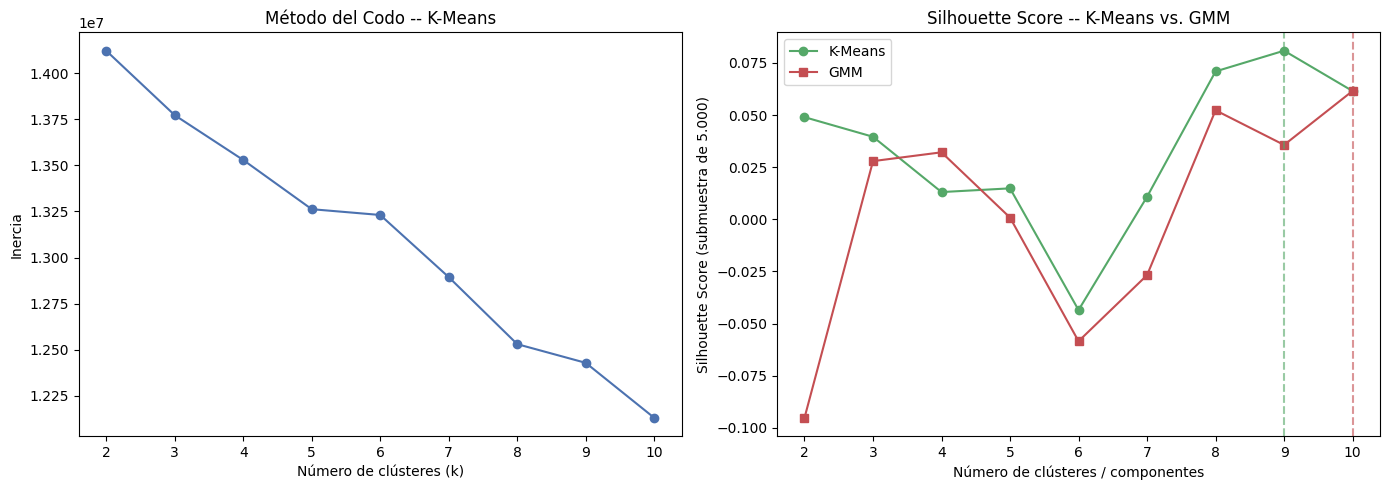

In [12]:
# Gráfica combinada: método del codo (K-Means) y Silhouette Score de ambos algoritmos
k_opt_preview = max(silhouette_kmeans, key=silhouette_kmeans.get)
n_opt_preview = max(silhouette_gmm, key=silhouette_gmm.get)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(rango_k), list(inercias.values()), marker='o', color='#4C72B0')
axes[0].set_xlabel('Número de clústeres (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo -- K-Means')
axes[0].set_xticks(list(rango_k))

axes[1].plot(list(rango_k), list(silhouette_kmeans.values()), marker='o', color='#55A868', label='K-Means')
axes[1].plot(list(rango_gmm), list(silhouette_gmm.values()), marker='s', color='#C44E52', label='GMM')
axes[1].axvline(k_opt_preview, color='#55A868', linestyle='--', alpha=0.6)
axes[1].axvline(n_opt_preview, color='#C44E52', linestyle='--', alpha=0.6)
axes[1].set_xlabel('Número de clústeres / componentes')
axes[1].set_ylabel('Silhouette Score (submuestra de 5.000)')
axes[1].set_title('Silhouette Score -- K-Means vs. GMM')
axes[1].set_xticks(list(rango_k))
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.4. Selección Final del Número de Clústeres

Se selecciona, para cada algoritmo, el número de clústeres/componentes que maximiza el Silhouette Score sobre la submuestra, salvo que el método del codo sugiera claramente un valor distinto para K-Means.

In [13]:
k_optimo_silhouette = max(silhouette_kmeans, key=silhouette_kmeans.get)
n_optimo_silhouette_gmm = max(silhouette_gmm, key=silhouette_gmm.get)

print("=== K-Means ===")
print(f"k que maximiza el Silhouette Score: {k_optimo_silhouette} (Silhouette = {silhouette_kmeans[k_optimo_silhouette]:.4f})")
print(f"Inercia en ese k: {inercias[k_optimo_silhouette]:,.1f}")
print("Evolución de la inercia (método del codo):")
for k, inercia in inercias.items():
    print(f"  k={k:>2}: {inercia:,.1f}")

print("\n=== GMM ===")
print(f"n_components que maximiza el Silhouette Score: {n_optimo_silhouette_gmm} (Silhouette = {silhouette_gmm[n_optimo_silhouette_gmm]:.4f})")

=== K-Means ===
k que maximiza el Silhouette Score: 9 (Silhouette = 0.0809)
Inercia en ese k: 12,428,552.8
Evolución de la inercia (método del codo):
  k= 2: 14,122,166.4
  k= 3: 13,772,412.8
  k= 4: 13,529,264.9
  k= 5: 13,262,265.8
  k= 6: 13,230,830.1
  k= 7: 12,893,652.1
  k= 8: 12,530,022.2
  k= 9: 12,428,552.8
  k=10: 12,130,151.3

=== GMM ===
n_components que maximiza el Silhouette Score: 10 (Silhouette = 0.0616)


Con los resultados anteriores:

- **K-Means**: la inercia decrece de forma monótona y suave en todo el rango 2-10, sin un "codo" geométrico claramente marcado. El Silhouette Score sí presenta un máximo claro en **k=9**, y la inercia en ese punto ya se encuentra en la zona de rendimientos decrecientes de la curva. El método del codo no contradice al Silhouette, así que se selecciona **k=9** para K-Means.
- **GMM**: el Silhouette Score máximo se alcanza en **n_components=10**, justo en el límite superior del rango explorado (2 a 10). Esto sugiere que el máximo real podría estar en un valor aún mayor, pero se selecciona **n_components=10** como solución final para GMM.

## 5. Entrenamiento de los Modelos Finales

Con el número de clústeres/componentes ya determinado en la Sección 4, se reutilizan los modelos ya entrenados sobre la totalidad del dataset durante la búsqueda de la Sección 4 (evita reentrenar innecesariamente: ya se entrenó un modelo por cada valor de *k*/n_components probado).

### 5.1. K-Means Final

In [14]:
K_FINAL = k_optimo_silhouette

kmeans_final = modelos_kmeans[K_FINAL]
df_uci['Cluster_KMeans'] = kmeans_final.labels_

print(f"K-Means final entrenado con k={K_FINAL} clústeres sobre {X_pca.shape[0]} pacientes.\n")
print("Distribución de pacientes por clúster:")
display(
    df_uci['Cluster_KMeans'].value_counts().sort_index().rename('N pacientes').to_frame()
    .assign(**{'% del total': lambda d: (100 * d['N pacientes'] / len(df_uci)).round(2)})
)

K-Means final entrenado con k=9 clústeres sobre 162009 pacientes.

Distribución de pacientes por clúster:


,N pacientes,% del total
Cluster_KMeans,,
0,13277,8.20
1,57270,35.35
2,21792,13.45
3,2122,1.31
4,56744,35.03
5,2579,1.59
6,588,0.36
7,5306,3.28
8,2331,1.44


### 5.2. GMM Final

In [15]:
N_FINAL_GMM = n_optimo_silhouette_gmm

gmm_final = modelos_gmm[N_FINAL_GMM]
df_uci['Cluster_GMM'] = gmm_final.predict(X_pca)

print(f"GMM final entrenado con {N_FINAL_GMM} componentes sobre {X_pca.shape[0]} pacientes.\n")
print("Distribución de pacientes por clúster:")
display(
    df_uci['Cluster_GMM'].value_counts().sort_index().rename('N pacientes').to_frame()
    .assign(**{'% del total': lambda d: (100 * d['N pacientes'] / len(df_uci)).round(2)})
)

GMM final entrenado con 10 componentes sobre 162009 pacientes.

Distribución de pacientes por clúster:


,N pacientes,% del total
Cluster_GMM,,
0,50422,31.12
1,2635,1.63
2,1415,0.87
3,20810,12.84
4,992,0.61
5,53134,32.80
6,1332,0.82
7,4860,3.00
8,20438,12.62


## 6. Perfilado de Clústeres

Para cada solución (K-Means y GMM) se genera una tabla resumen por clúster con: edad media, valores medios de las constantes vitales, prevalencia (%) de cada comorbilidad, y diagnóstico de admisión y servicio dominantes. Se define una función reutilizable, ya que el mismo perfilado se aplica a ambas soluciones de clustering.

In [16]:
def perfilar_clusters(df, columna_cluster):
    # Genera una tabla resumen por clúster: tamaño, edad, vitales, comorbilidades y categóricas dominantes
    n_total = len(df)
    filas = []

    for cluster_id in sorted(df[columna_cluster].unique()):
        sub = df[df[columna_cluster] == cluster_id]

        fila = {
            'Cluster': cluster_id,
            'N pacientes': len(sub),
            '% del total': round(100 * len(sub) / n_total, 2),
            'Edad media': round(sub['Age'].mean(), 1),
            'FC media (lpm)': round(sub['HeartRate_Admission'].mean(), 1),
            'FR media (rpm)': round(sub['RespiratoryRate_Admission'].mean(), 1),
            'PAM media (mmHg)': round(sub['MeanBP_Admission'].mean(), 1),
            'Temp. media (°C)': round(sub['Temperature'].mean(), 1),
        }

        for com in comorbilidades:
            fila[f'{com} (%)'] = round(100 * sub[com].mean(), 1)

        diag_top = sub['DiagnosisAdmission'].mode().iloc[0]
        fila['Diagnóstico más frecuente'] = diag_top
        fila['% ese diagnóstico'] = round(100 * (sub['DiagnosisAdmission'] == diag_top).mean(), 1)

        serv_top = sub['Service'].mode().iloc[0]
        fila['Servicio más frecuente'] = serv_top
        fila['% ese servicio'] = round(100 * (sub['Service'] == serv_top).mean(), 1)

        filas.append(fila)

    return pd.DataFrame(filas).set_index('Cluster')

print("Función 'perfilar_clusters' definida.")

Función 'perfilar_clusters' definida.


### 6.1. Perfil de Clústeres - K-Means

In [17]:
perfil_kmeans = perfilar_clusters(df_uci, 'Cluster_KMeans')
display(
    perfil_kmeans.style
        .background_gradient(cmap='Oranges', subset=[f'{c} (%)' for c in comorbilidades])
        .background_gradient(cmap='Blues', subset=['Edad media'])
)

,N pacientes,% del total,Edad media,FC media (lpm),FR media (rpm),PAM media (mmHg),Temp. media (°C),Diabetes (%),Cirrhosis (%),HepaticFailure (%),MetastaticCancer (%),Leukemia (%),Immunosuppression (%),MI (%),Diagnóstico más frecuente,% ese diagnóstico,Servicio más frecuente,% ese servicio
Cluster,,,,,,,,,,,,,,,,,,
0,13277,8.200000,66.300000,105.300000,29.800000,86.100000,36.500000,22.000000,1.100000,0.800000,2.700000,0.900000,3.800000,0.500000,Emphysema/bronchitis,30.000000,pulmonary,100.000000
1,57270,35.350000,67.100000,92.200000,24.100000,90.900000,36.300000,24.600000,0.600000,0.400000,1.400000,0.600000,1.600000,1.900000,"Infarction, acute myocardial (MI)",11.400000,cardiovascular,80.700000
2,21792,13.450000,65.700000,111.100000,29.800000,75.600000,36.600000,25.400000,2.800000,2.100000,3.300000,1.600000,5.600000,0.500000,"Sepsis, pulmonary",37.300000,infectious diseases,100.000000
3,2122,1.310000,65.000000,98.100000,25.600000,83.700000,36.300000,33.700000,3.200000,2.400000,1.900000,1.000000,2.600000,0.700000,"Renal failure, acute",100.000000,renal,100.000000
4,56744,35.030000,58.800000,102.300000,24.000000,86.800000,36.500000,15.900000,3.100000,2.900000,2.500000,0.600000,2.900000,0.300000,Other Diagnosis,47.700000,gastrointestinal,24.400000
5,2579,1.590000,62.100000,99.300000,26.000000,90.200000,36.500000,24.500000,1.900000,1.200000,1.900000,1.000000,2.000000,0.400000,"Coma/change in level of consciousness (for hepatic see GI, for diabetic see Endocrine, if related to cardiac arrest, see CV)",100.000000,neurologic,100.000000
6,588,0.360000,41.800000,110.600000,24.200000,88.000000,36.500000,3.400000,1.000000,0.700000,0.200000,0.000000,0.200000,0.200000,"Overdose, alcohols (bethanol, methanol, ethylene glycol)",100.000000,toxicology,100.000000
7,5306,3.280000,43.800000,110.300000,22.300000,82.700000,36.500000,79.700000,0.600000,0.400000,0.500000,0.200000,0.800000,0.200000,Diabetic ketoacidosis,86.200000,endocrine,100.000000
8,2331,1.440000,65.100000,105.700000,26.000000,82.000000,36.500000,25.700000,1.900000,1.900000,2.700000,0.900000,3.500000,0.600000,"Arrest, respiratory (without cardiac arrest)",100.000000,pulmonary,100.000000


### 6.2. Perfil de Clústeres - GMM

In [18]:
perfil_gmm = perfilar_clusters(df_uci, 'Cluster_GMM')
display(
    perfil_gmm.style
        .background_gradient(cmap='Oranges', subset=[f'{c} (%)' for c in comorbilidades])
        .background_gradient(cmap='Blues', subset=['Edad media'])
)

,N pacientes,% del total,Edad media,FC media (lpm),FR media (rpm),PAM media (mmHg),Temp. media (°C),Diabetes (%),Cirrhosis (%),HepaticFailure (%),MetastaticCancer (%),Leukemia (%),Immunosuppression (%),MI (%),Diagnóstico más frecuente,% ese diagnóstico,Servicio más frecuente,% ese servicio
Cluster,,,,,,,,,,,,,,,,,,
0,50422,31.120000,65.100000,93.800000,24.100000,87.300000,36.300000,24.500000,0.600000,0.500000,1.000000,0.500000,1.500000,2.000000,Other Diagnosis,13.700000,cardiovascular,93.100000
1,2635,1.630000,64.900000,113.400000,28.800000,73.200000,36.500000,20.600000,6.600000,5.800000,4.700000,1.100000,6.800000,0.500000,"Sepsis, GI",100.000000,infectious diseases,100.000000
2,1415,0.870000,43.600000,96.800000,23.300000,84.600000,36.400000,6.600000,0.400000,0.300000,0.300000,0.100000,0.400000,0.100000,"Overdose, sedatives, hypnotics, antipsychotics, benzodiazepines",100.000000,toxicology,100.000000
3,20810,12.840000,62.300000,93.600000,23.700000,99.400000,36.500000,17.600000,1.100000,0.700000,2.600000,0.600000,2.200000,0.300000,"CVA, cerebrovascular accident/stroke",28.800000,neurologic,100.000000
4,992,0.610000,71.900000,110.100000,23.300000,86.000000,36.400000,15.600000,0.900000,0.900000,2.100000,0.400000,2.700000,0.600000,"GI obstruction, surgery for (including lysis of adhesions)",100.000000,gastrointestinal,100.000000
5,53134,32.800000,62.600000,104.200000,25.900000,85.400000,36.500000,19.800000,3.300000,3.100000,2.800000,0.800000,3.400000,0.500000,Other Diagnosis,40.200000,pulmonary,34.300000
6,1332,0.820000,63.900000,96.100000,23.500000,83.500000,36.500000,4.700000,0.500000,0.300000,0.700000,0.000000,1.100000,0.600000,Unknown,100.000000,unknown,100.000000
7,4860,3.000000,68.100000,108.700000,28.600000,74.500000,36.600000,28.700000,1.800000,1.200000,2.600000,0.800000,3.400000,0.400000,"Sepsis, renal/UTI (including bladder)",100.000000,infectious diseases,100.000000
8,20438,12.620000,63.800000,107.900000,28.400000,80.200000,36.600000,23.300000,2.100000,1.500000,3.200000,1.500000,5.100000,0.500000,"Sepsis, pulmonary",39.700000,infectious diseases,73.600000


## 7. Validación Post-Hoc: Tasa de Mortalidad Real por Clúster

`DiedInHospital` no ha participado en ningún momento del proceso de clustering. Se recupera ahora únicamente como **validación externa**, si alguno de los clústeres obtenidos de forma no supervisada presenta una tasa de mortalidad real notablemente distinta de la media global, es una señal de que el fenotipo encontrado tiene significado clínico real, no solo estadístico.

In [19]:
def tasa_mortalidad_por_cluster(df, columna_cluster):
    # Calcula la tasa de mortalidad real observada en cada clúster, frente a la tasa global
    tasa_global = df['DiedInHospital'].mean()

    tabla = df.groupby(columna_cluster)['DiedInHospital'].agg(['mean', 'count'])
    tabla.columns = ['Tasa mortalidad', 'N pacientes']
    tabla['Tasa mortalidad (%)'] = (tabla['Tasa mortalidad'] * 100).round(2)
    tabla['Diferencia vs. media global (p.p.)'] = (tabla['Tasa mortalidad (%)'] - tasa_global * 100).round(2)
    tabla = tabla.drop(columns='Tasa mortalidad')

    return tabla, tasa_global

print("Función 'tasa_mortalidad_por_cluster' definida.")

Función 'tasa_mortalidad_por_cluster' definida.


### 7.1. Mortalidad por Clúster - K-Means

Tasa de mortalidad global del dataset: 9.14%



,N pacientes,Tasa mortalidad (%),Diferencia vs. media global (p.p.)
Cluster_KMeans,,,
0,13277,11.64,+2.50
1,57270,9.08,-0.06
2,21792,16.21,+7.07
3,2122,7.87,-1.27
4,56744,6.31,-2.83
5,2579,8.69,-0.45
6,588,0.00,-9.14
7,5306,0.98,-8.16
8,2331,21.41,+12.27


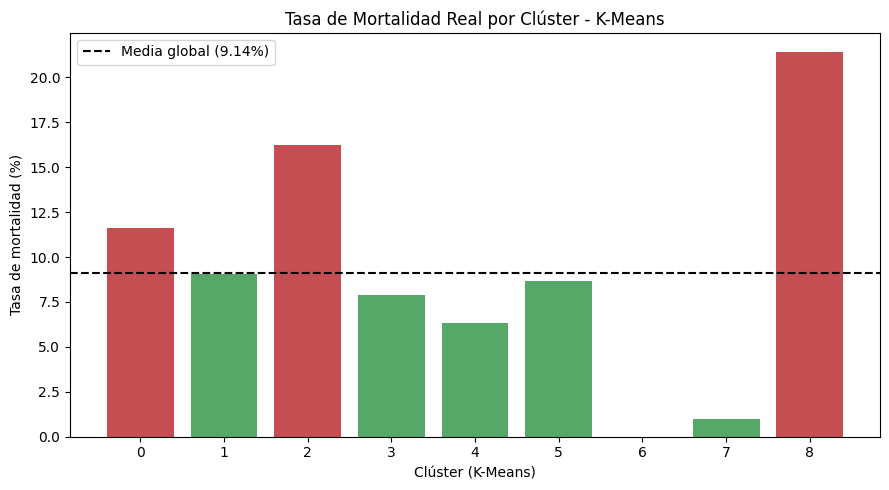

In [20]:
tabla_mortalidad_kmeans, tasa_global = tasa_mortalidad_por_cluster(df_uci, 'Cluster_KMeans')

print(f"Tasa de mortalidad global del dataset: {tasa_global * 100:.2f}%\n")
display(
    tabla_mortalidad_kmeans.style
        .background_gradient(cmap='Reds', subset=['Tasa mortalidad (%)'])
        .format({'Tasa mortalidad (%)': '{:.2f}', 'Diferencia vs. media global (p.p.)': '{:+.2f}'})
)

fig, ax = plt.subplots(figsize=(9, 5))
colores = ['#C44E52' if v > 0 else '#55A868' for v in tabla_mortalidad_kmeans['Diferencia vs. media global (p.p.)']]
ax.bar(tabla_mortalidad_kmeans.index.astype(str), tabla_mortalidad_kmeans['Tasa mortalidad (%)'], color=colores)
ax.axhline(tasa_global * 100, color='black', linestyle='--', label=f'Media global ({tasa_global * 100:.2f}%)')
ax.set_xlabel('Clúster (K-Means)')
ax.set_ylabel('Tasa de mortalidad (%)')
ax.set_title('Tasa de Mortalidad Real por Clúster - K-Means')
ax.legend()
plt.tight_layout()
plt.show()

### 7.2. Mortalidad por Clúster - GMM

Tasa de mortalidad global del dataset: 9.14%



,N pacientes,Tasa mortalidad (%),Diferencia vs. media global (p.p.)
Cluster_GMM,,,
0,50422,8.32,-0.82
1,2635,20.08,+10.94
2,1415,0.78,-8.36
3,20810,8.21,-0.93
4,992,10.38,+1.24
5,53134,8.08,-1.06
6,1332,13.29,+4.15
7,4860,11.05,+1.91
8,20438,15.55,+6.41


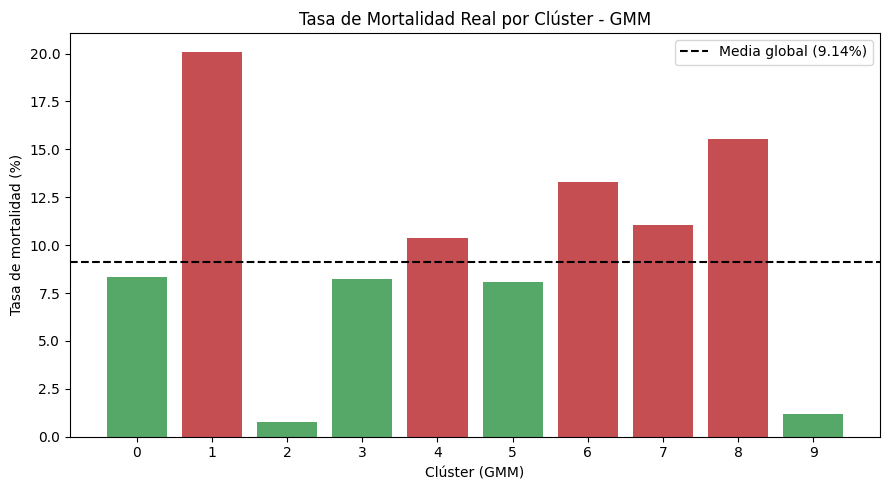

In [21]:
tabla_mortalidad_gmm, _ = tasa_mortalidad_por_cluster(df_uci, 'Cluster_GMM')

print(f"Tasa de mortalidad global del dataset: {tasa_global * 100:.2f}%\n")
display(
    tabla_mortalidad_gmm.style
        .background_gradient(cmap='Reds', subset=['Tasa mortalidad (%)'])
        .format({'Tasa mortalidad (%)': '{:.2f}', 'Diferencia vs. media global (p.p.)': '{:+.2f}'})
)

fig, ax = plt.subplots(figsize=(9, 5))
colores = ['#C44E52' if v > 0 else '#55A868' for v in tabla_mortalidad_gmm['Diferencia vs. media global (p.p.)']]
ax.bar(tabla_mortalidad_gmm.index.astype(str), tabla_mortalidad_gmm['Tasa mortalidad (%)'], color=colores)
ax.axhline(tasa_global * 100, color='black', linestyle='--', label=f'Media global ({tasa_global * 100:.2f}%)')
ax.set_xlabel('Clúster (GMM)')
ax.set_ylabel('Tasa de mortalidad (%)')
ax.set_title('Tasa de Mortalidad Real por Clúster - GMM')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Comparación Final: K-Means vs. GMM

Se comparan ambas soluciones de clustering desde tres ángulos. (1) el grado de coincidencia estructural entre las dos particiones, mediante el *Adjusted Rand Index* (ARI), (2) una tabla de contingencia cruzando ambas asignaciones y (3) la coherencia de las tasas de mortalidad encontradas en cada solución.

### 8.1. Adjusted Rand Index (ARI)

El ARI mide el grado de acuerdo entre dos particiones del mismo conjunto de datos, corrigiendo por el acuerdo esperable por azar. Va de -1 (total desacuerdo) a 1 (partición idéntica), un valor de 0 equivale a un acuerdo puramente aleatorio.

In [22]:
ari = adjusted_rand_score(df_uci['Cluster_KMeans'], df_uci['Cluster_GMM'])
print(f"Adjusted Rand Index (K-Means vs. GMM): {ari:.4f}")

Adjusted Rand Index (K-Means vs. GMM): 0.5110


### 8.2. Tabla de Contingencia

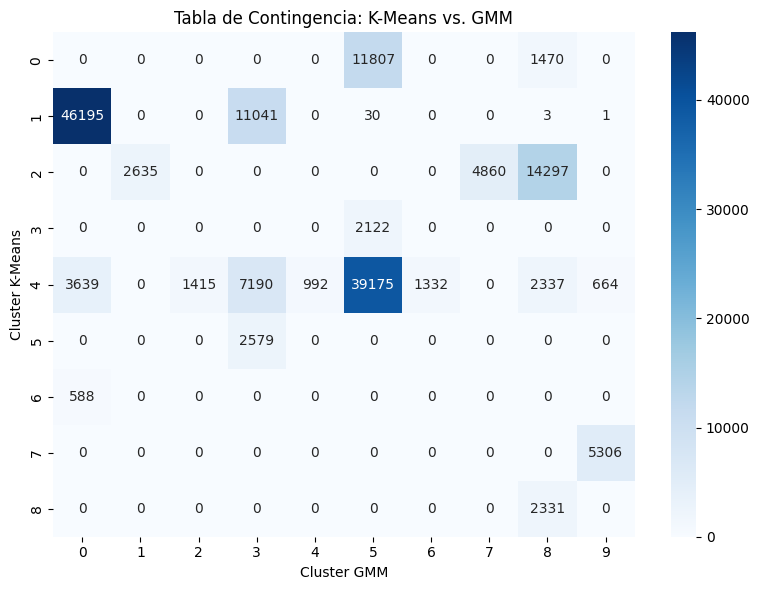

Cluster GMM,0,1,2,3,4,5,6,7,8,9
Cluster K-Means,,,,,,,,,,
0,0,0,0,0,0,11807,0,0,1470,0
1,46195,0,0,11041,0,30,0,0,3,1
2,0,2635,0,0,0,0,0,4860,14297,0
3,0,0,0,0,0,2122,0,0,0,0
4,3639,0,1415,7190,992,39175,1332,0,2337,664
5,0,0,0,2579,0,0,0,0,0,0
6,588,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,5306
8,0,0,0,0,0,0,0,0,2331,0


In [23]:
tabla_contingencia = pd.crosstab(df_uci['Cluster_KMeans'], df_uci['Cluster_GMM'])
tabla_contingencia.index.name = 'Cluster K-Means'
tabla_contingencia.columns.name = 'Cluster GMM'

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(tabla_contingencia, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Tabla de Contingencia: K-Means vs. GMM')
plt.tight_layout()
plt.show()

display(tabla_contingencia)

### 8.3. Comparación de Tasas de Mortalidad por Clúster

In [24]:
comparacion_mortalidad = pd.DataFrame({
    'K-Means - Tasa mortalidad (%)': tabla_mortalidad_kmeans['Tasa mortalidad (%)'].sort_values(ascending=False).values,
    'K-Means - N pacientes': tabla_mortalidad_kmeans['N pacientes'].loc[tabla_mortalidad_kmeans['Tasa mortalidad (%)'].sort_values(ascending=False).index].values,
}, index=pd.RangeIndex(1, len(tabla_mortalidad_kmeans) + 1)).rename_axis('Ranking (mayor a menor mortalidad)')

comparacion_mortalidad_gmm = pd.DataFrame({
    'GMM - Tasa mortalidad (%)': tabla_mortalidad_gmm['Tasa mortalidad (%)'].sort_values(ascending=False).values,
    'GMM - N pacientes': tabla_mortalidad_gmm['N pacientes'].loc[tabla_mortalidad_gmm['Tasa mortalidad (%)'].sort_values(ascending=False).index].values,
}, index=pd.RangeIndex(1, len(tabla_mortalidad_gmm) + 1)).rename_axis('Ranking (mayor a menor mortalidad)')

display(comparacion_mortalidad.join(comparacion_mortalidad_gmm, how='outer'))

print(f"\nRango de tasas de mortalidad - K-Means: [{tabla_mortalidad_kmeans['Tasa mortalidad (%)'].min():.2f}%, {tabla_mortalidad_kmeans['Tasa mortalidad (%)'].max():.2f}%]")
print(f"Rango de tasas de mortalidad - GMM:      [{tabla_mortalidad_gmm['Tasa mortalidad (%)'].min():.2f}%, {tabla_mortalidad_gmm['Tasa mortalidad (%)'].max():.2f}%]")

,K-Means - Tasa mortalidad (%),K-Means - N pacientes,GMM - Tasa mortalidad (%),GMM - N pacientes
Ranking (mayor a menor mortalidad),,,,
1,21.41,2331.0,20.08,2635
2,16.21,21792.0,15.55,20438
3,11.64,13277.0,13.29,1332
4,9.08,57270.0,11.05,4860
5,8.69,2579.0,10.38,992
6,7.87,2122.0,8.32,50422
7,6.31,56744.0,8.21,20810
8,0.98,5306.0,8.08,53134
9,0.00,588.0,1.17,5971



Rango de tasas de mortalidad - K-Means: [0.00%, 21.41%]
Rango de tasas de mortalidad - GMM:      [0.78%, 20.08%]


### 8.4. Interpretación de la Comparación

**Grado de acuerdo estructural:** un ARI de 0.5110 indica un acuerdo **moderado-sustancial** entre ambas particiones, muy por encima de 0 (acuerdo esperable por azar) pero lejos de 1 (partición idéntica). Es coherente con el hecho de que K-Means y GMM seleccionaron un número de clústeres distinto (9 frente a 10) y con que GMM permite fronteras probabilísticas más suaves entre grupos, mientras que K-Means impone fronteras duras por distancia al centroide.

**Coherencia clínica entre soluciones:** pese a no coincidir exactamente en número ni límites de clúster, **ambos algoritmos aíslan de forma independiente los mismos dos extremos clínicos**:

- **Fenotipo de bajo riesgo.** pacientes jóvenes (edad media ~42-46 años) ingresados por intoxicación por tóxicos/sedantes o cetoacidosis diabética (servicios *toxicology*/*endocrine*), mortalidad 0.00% y 0.98% en K-Means, 0.78% y 1.17% en GMM, muy por debajo del 9.14% global.
- **Fenotipo de alto riesgo.** pacientes con sepsis pulmonar/gastrointestinal o parada respiratoria (servicios *pulmonary*/*infectious diseases*), mortalidad hasta 21.41% en K-Means y 20.08% en GMM, más del doble de la tasa global.

Que dos algoritmos con lógicas de agrupación distintas (distancia a centroide vs. densidad probabilística) converjan de forma independiente en los mismos fenotipos extremos es una validación más sólida que la que ofrecería cualquiera de los dos algoritmos por separado, la señal no depende del método concreto, sino que está presente en la estructura real de los datos.

## 9. Visualización 2D (PCA) de los Clústeres

Proyección de todos los pacientes sobre los dos primeros componentes principales (los de mayor varianza explicada), coloreada por clúster, para inspeccionar visualmente el grado de separación entre grupos en ambas soluciones. Con 162.009 puntos se usa transparencia (`alpha`) para mitigar el sobre-trazado.

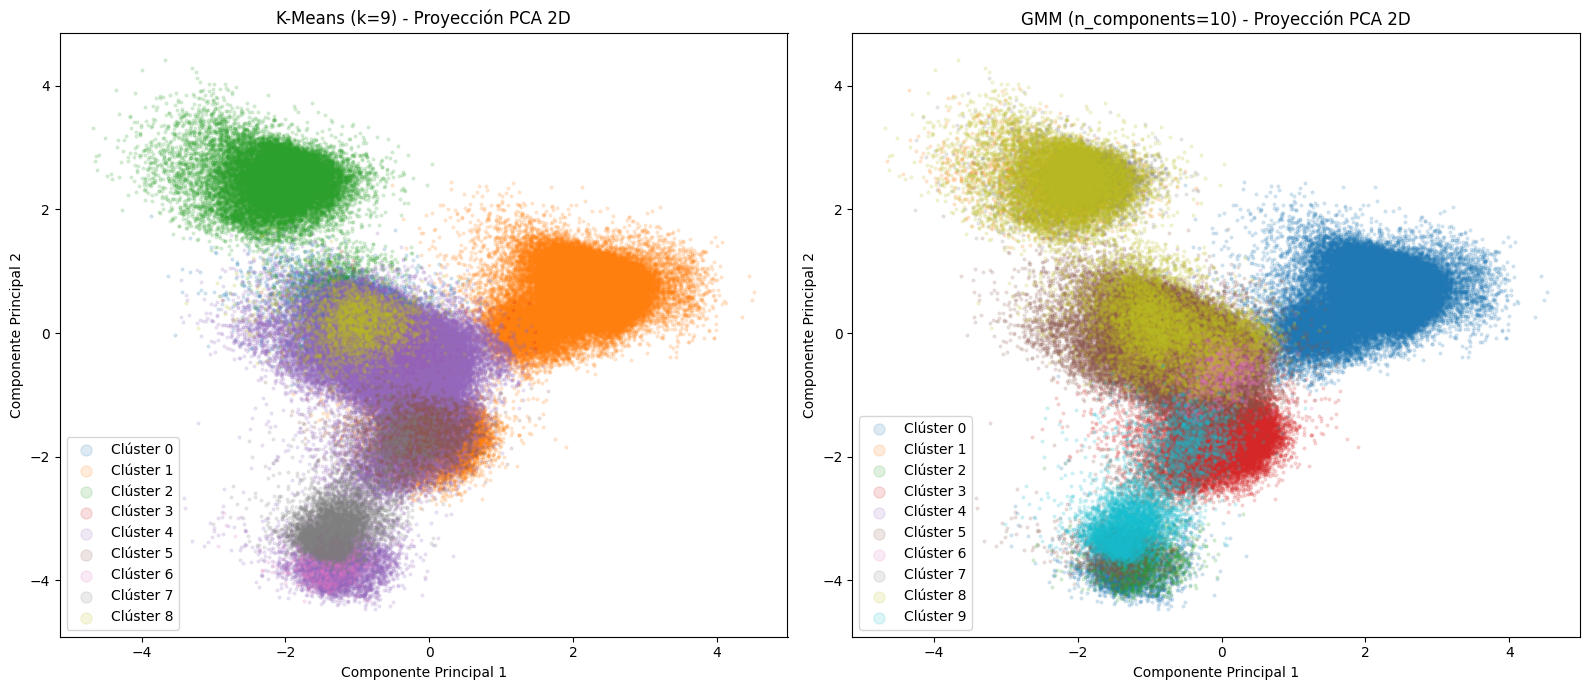

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

paleta_kmeans = sns.color_palette('tab10', n_colors=df_uci['Cluster_KMeans'].nunique())
for cluster_id, color in zip(sorted(df_uci['Cluster_KMeans'].unique()), paleta_kmeans):
    mask = df_uci['Cluster_KMeans'] == cluster_id
    axes[0].scatter(X_pca[mask.values, 0], X_pca[mask.values, 1], s=4, alpha=0.15, color=color, label=f'Clúster {cluster_id}')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')
axes[0].set_title(f'K-Means (k={K_FINAL}) - Proyección PCA 2D')
leg0 = axes[0].legend(markerscale=4, loc='best')

paleta_gmm = sns.color_palette('tab10', n_colors=df_uci['Cluster_GMM'].nunique())
for cluster_id, color in zip(sorted(df_uci['Cluster_GMM'].unique()), paleta_gmm):
    mask = df_uci['Cluster_GMM'] == cluster_id
    axes[1].scatter(X_pca[mask.values, 0], X_pca[mask.values, 1], s=4, alpha=0.15, color=color, label=f'Clúster {cluster_id}')
axes[1].set_xlabel('Componente Principal 1')
axes[1].set_ylabel('Componente Principal 2')
axes[1].set_title(f'GMM (n_components={N_FINAL_GMM}) - Proyección PCA 2D')
leg1 = axes[1].legend(markerscale=4, loc='best')

plt.tight_layout()
plt.show()

## 10. Dudas Planteadas tras el Modelo Inicial

El modelo inicial (Secciones 1-9) se entrenó con `DiagnosisAdmission` incluida y un rango de búsqueda de k/n_components de 2 a 10, seleccionando **k=9 para K-Means** (Silhouette=0.0809) y **n=10 para GMM** (Silhouette=0.0616). Antes de dar ese modelo por definitivo surgen dos dudas:

1. **¿El rango k/n_components = 2..10 se queda corto?** El óptimo de GMM cayó justo en el borde del rango probado (n=10), una señal típica de que el verdadero óptimo podría estar más allá.
2. **¿`DiagnosisAdmission` domina el clustering?** Con 70 categorías, es la variable que más dimensiones aporta (69 de las 98 columnas finales tras el One-Hot Encoding). El perfilado de la Sección 6 mostró clústeres con un único diagnóstico dominante al 76-100%, una señal de que el clustering podría reducirse a "agrupar por diagnóstico" en lugar de encontrar fenotipos que combinen comorbilidades, vitales y diagnóstico.

## 11. Resumen del Proceso de Validación de las Dudas

Ambas dudas se investigaron mediante un conjunto de pruebas adicionales, ampliando progresivamente el rango de búsqueda (2-10 → 2-20 → 2-30) y comparando explícitamente la inclusión frente a la exclusión de `DiagnosisAdmission`, siempre sobre el mismo pipeline (One-Hot + `StandardScaler` + PCA al 90% de varianza + K-Means/GMM) y aplicando un **filtro anti-clúster-trivial** para descartar cualquier solución cuyo clúster más pequeño tenga menos de 100 pacientes, porque al ampliar el rango ambos algoritmos empiezan, a partir de cierto punto, a aislar como clúster propio una categoría administrativa minoritaria de `Service` (p. ej. *obstetrics/gynecology*, con solo 17 pacientes en todo el dataset), lo que infla el Silhouette de forma artificial sin aportar una segmentación multivariante real.

No se reproduce aquí cada prueba, pero sí se deja el resultado agregado de cada configuración, siendo los datos que justifican la decisión final:

| Configuración | Rango probado | k/n óptimo (K-Means / GMM) | Silhouette máx. (K-Means / GMM) | ARI K-Means vs. GMM |
|---|---|---|---|---|
| Con `DiagnosisAdmission` | 2-10 | 9 / 10 | 0.0809 / 0.0616 | 0.5110 |
| Con `DiagnosisAdmission` | 2-30 | **30 / 30** (en el borde, sin converger) | 0.2187 / 0.2310 | **0.3601** |
| Sin `DiagnosisAdmission` | 2-10 | 10 / 10 | 0.2733 / 0.2580 | 0.6775 |
| Sin `DiagnosisAdmission` | 2-30 | **15 / 13** (estable, no cambia con el rango) | 0.3599 / 0.3301 | **0.9101** |

**Lectura de la tabla:**

- **Con diagnóstico, el rango sí se quedaba corto pero ampliarlo no resuelve nada.** El óptimo nunca deja de estar en el borde del rango probado (ni siquiera con 2-30), y el precio de perseguirlo es que **el acuerdo entre K-Means y GMM empeora** cuantos más clústeres se piden (ARI 0.51 → 0.36). Cada algoritmo empieza a ajustar estructura cada vez más específica de sí mismo, no necesariamente estructura real compartida en los datos. Es una búsqueda que no converge.
- **Sin diagnóstico, la mejora ya se nota en el propio rango 2-10** (Silhouette 0.27/0.26 frente a 0.08/0.06 con diagnóstico, ARI 0.68 frente a 0.51. También mejor concordancia entre algoritmos, aunque el óptimo real de K-Means y GMM todavía no coinciden en el mismo valor de k dentro de un rango tan corto). El verdadero óptimo **k=15/n=13** solo aparece al ampliar el rango más allá de 10, y una vez que aparece **ya no se mueve**, es el mismo con rango 2-20 o 2-30, y ahí la concordancia entre algoritmos sube hasta ARI≈0.91. Es un óptimo genuino y estable, no un artefacto del límite superior del rango probado.

**Conclusión de las pruebas:** la mejora no viene de ampliar k manteniendo `DiagnosisAdmission`, esa vía no converge y degrada el consenso entre algoritmos. Viene de **retirar `DiagnosisAdmission`**, lo que produce una segmentación con óptimo estable, mucho mejor Silhouette y una concordancia entre algoritmos casi total. Sobre esa base se construye el modelo final, **sin `DiagnosisAdmission`, buscando en un rango de k/n_components = 2 a 20** (suficiente para confirmar el óptimo en 15/13 sin necesidad de llegar a 30, donde todo lo que hay más allá de 15-16 es ya trivial).

## 12. Modelo Final - Sin `DiagnosisAdmission` (k = 2..20)

Se repite el pipeline del modelo inicial (mismas comorbilidades, vitales/edad; `Service` como única variable categórica, sin `DiagnosisAdmission`), reutilizando las funciones `perfilar_clusters` y `tasa_mortalidad_por_cluster` ya definidas en las Secciones 6 y 7. Se añaden dos funciones nuevas para encapsular el preprocesado y la búsqueda de k con el filtro anti-clúster-trivial ya justificado en la Sección 11.

### 12.1. Funciones Adicionales del Pipeline

In [26]:
def preparar_matriz_pca(df, columnas_categoricas, random_state=RANDOM_STATE):
    # Codifica (One-Hot), escala y aplica PCA (90% varianza explicada) sobre
    # comorbilidades + vitales/edad + las columnas categóricas indicadas.
    encoder_local = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
    cat_encoded = encoder_local.fit_transform(df[columnas_categoricas])
    encoded_cols = encoder_local.get_feature_names_out(columnas_categoricas)

    X = pd.concat([
        df[comorbilidades + vitales_edad].reset_index(drop=True),
        pd.DataFrame(cat_encoded, columns=encoded_cols)
    ], axis=1)

    scaler_local = StandardScaler()
    X_scaled = scaler_local.fit_transform(X)

    pca_local = PCA(n_components=0.90, random_state=random_state)
    X_pca_local = pca_local.fit_transform(X_scaled)

    print(f"Variables categóricas codificadas: {columnas_categoricas}")
    print(f"Dimensiones antes de PCA: {X_scaled.shape[1]} variables")
    print(f"Componentes principales retenidos (90% varianza): {X_pca_local.shape[1]}")

    return X_pca_local, encoder_local, scaler_local, pca_local, X_scaled


def buscar_numero_clusters(X_pca_in, idx_muestra, rango, min_tamano_cluster=100, random_state=RANDOM_STATE, verbose=True):
    # Busca k (K-Means) / n_components (GMM) óptimos sobre 'rango', descartando
    # soluciones triviales (clúster con menos de min_tamano_cluster pacientes).
    X_muestra = X_pca_in[idx_muestra]

    inercias_local, sil_km, modelos_km = {}, {}, {}
    sil_gmm, modelos_gmm, etiquetas_gmm = {}, {}, {}

    for k in rango:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10).fit(X_pca_in)
        modelos_km[k] = km
        inercias_local[k] = km.inertia_
        sil_km[k] = silhouette_score(X_muestra, km.labels_[idx_muestra])
        tam_min_km = np.bincount(km.labels_).min()

        gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=random_state, n_init=1)
        gmm.fit(X_pca_in)
        modelos_gmm[k] = gmm
        etiquetas = gmm.predict(X_pca_in)
        etiquetas_gmm[k] = etiquetas
        sil_gmm[k] = silhouette_score(X_muestra, etiquetas[idx_muestra])
        tam_min_gmm = np.bincount(etiquetas).min()

        if verbose:
            aviso_km = '  [TRIVIAL]' if tam_min_km < min_tamano_cluster else ''
            aviso_gmm = '  [TRIVIAL]' if tam_min_gmm < min_tamano_cluster else ''
            print(f"k={k:>2} | K-Means: inercia={km.inertia_:>13,.1f}  sil={sil_km[k]:.4f}  clúster_min={tam_min_km:>6}{aviso_km}"
                  f"   ||   GMM: sil={sil_gmm[k]:.4f}  clúster_min={tam_min_gmm:>6}{aviso_gmm}")

    candidatos_km = {k: s for k, s in sil_km.items() if np.bincount(modelos_km[k].labels_).min() >= min_tamano_cluster}
    candidatos_gmm = {k: s for k, s in sil_gmm.items() if np.bincount(etiquetas_gmm[k]).min() >= min_tamano_cluster}

    k_final_local = max(candidatos_km, key=candidatos_km.get)
    n_final_local = max(candidatos_gmm, key=candidatos_gmm.get)

    print(f"\n>>> K-Means óptimo (excluyendo triviales, <{min_tamano_cluster} pacientes): k={k_final_local} (Silhouette={candidatos_km[k_final_local]:.4f})")
    print(f">>> GMM óptimo (excluyendo triviales, <{min_tamano_cluster} pacientes):     n={n_final_local} (Silhouette={candidatos_gmm[n_final_local]:.4f})")

    return {
        'inercias': inercias_local, 'sil_km': sil_km, 'sil_gmm': sil_gmm,
        'modelos_km': modelos_km, 'modelos_gmm': modelos_gmm, 'etiquetas_gmm': etiquetas_gmm,
        'candidatos_km': candidatos_km, 'candidatos_gmm': candidatos_gmm,
        'k_final': k_final_local, 'n_final': n_final_local,
    }


def graficar_busqueda_k(resultado, rango, titulo_sufijo=''):
    # Grafica el método del codo (K-Means) y el Silhouette Score de ambos algoritmos.
    # Los puntos en gris son soluciones descartadas por producir un clúster trivial.
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    k_vals = list(rango)
    axes[0].plot(k_vals, [resultado['inercias'][k] for k in k_vals], marker='o', color='#4C72B0')
    axes[0].set_xlabel('Número de clústeres (k)')
    axes[0].set_ylabel('Inercia')
    axes[0].set_title(f'Método del Codo - K-Means {titulo_sufijo}')

    sil_km_vals = [resultado['sil_km'][k] for k in k_vals]
    sil_gmm_vals = [resultado['sil_gmm'][k] for k in k_vals]
    colores_km = ['#55A868' if k in resultado['candidatos_km'] else '#B0B0B0' for k in k_vals]
    colores_gmm = ['#C44E52' if k in resultado['candidatos_gmm'] else '#B0B0B0' for k in k_vals]

    axes[1].plot(k_vals, sil_km_vals, color='#55A868', alpha=0.3, zorder=1, label='_nolegend_')
    axes[1].scatter(k_vals, sil_km_vals, c=colores_km, zorder=2, label='K-Means')
    axes[1].plot(k_vals, sil_gmm_vals, color='#C44E52', alpha=0.3, zorder=1, label='_nolegend_')
    axes[1].scatter(k_vals, sil_gmm_vals, c=colores_gmm, marker='s', zorder=2, label='GMM')
    axes[1].axvline(resultado['k_final'], color='#55A868', linestyle='--', alpha=0.6)
    axes[1].axvline(resultado['n_final'], color='#C44E52', linestyle='--', alpha=0.6)
    axes[1].set_xlabel('Número de clústeres / componentes')
    axes[1].set_ylabel('Silhouette Score (submuestra)')
    axes[1].set_title(f'Silhouette Score {titulo_sufijo}\n(gris = descartado por trivial)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

print("Funciones 'preparar_matriz_pca', 'buscar_numero_clusters' y 'graficar_busqueda_k' definidas.")

Funciones 'preparar_matriz_pca', 'buscar_numero_clusters' y 'graficar_busqueda_k' definidas.


### 12.2. Preprocesado (sin `DiagnosisAdmission`)

In [27]:
categoricas_final = ['Service']

print("=== MODELO FINAL: preprocesado (sin DiagnosisAdmission) ===\n")
X_pca_final, encoder_final, scaler_final, pca_final, X_scaled_final = preparar_matriz_pca(df_uci, categoricas_final)

=== MODELO FINAL: preprocesado (sin DiagnosisAdmission) ===

Variables categóricas codificadas: ['Service']
Dimensiones antes de PCA: 29 variables
Componentes principales retenidos (90% varianza): 24


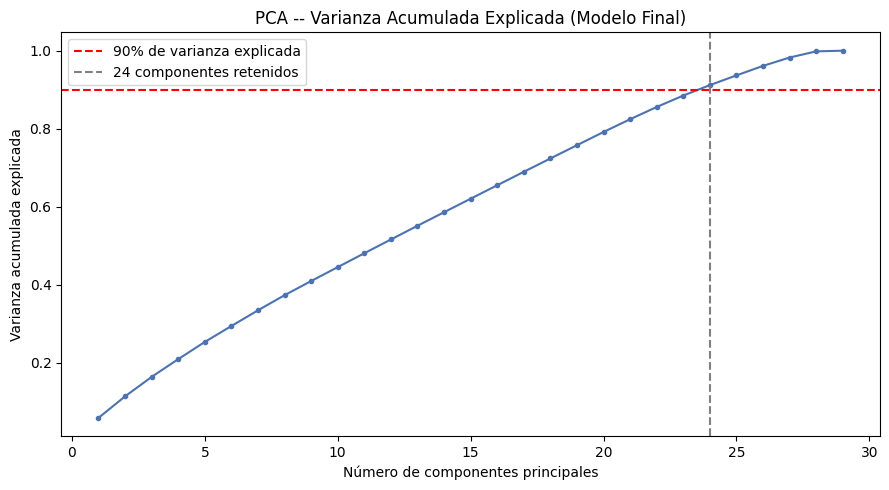

In [28]:
# Visualización de la varianza acumulada explicada por componente (Modelo Final)
varianza_acumulada_total_final = np.cumsum(PCA(random_state=RANDOM_STATE).fit(X_scaled_final).explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(varianza_acumulada_total_final) + 1), varianza_acumulada_total_final, marker='.', color='#4C72B0')
ax.axhline(0.90, color='red', linestyle='--', label='90% de varianza explicada')
ax.axvline(pca_final.n_components_, color='gray', linestyle='--', label=f'{pca_final.n_components_} componentes retenidos')
ax.set_xlabel('Número de componentes principales')
ax.set_ylabel('Varianza acumulada explicada')
ax.set_title('PCA -- Varianza Acumulada Explicada (Modelo Final)')
ax.legend()
plt.tight_layout()
plt.show()

### 12.3. Búsqueda del Número de Clústeres (k = 2..20)

In [29]:
RANGO_K_FINAL = range(2, 21)

print("=== MODELO FINAL: búsqueda de k/n_components (2..20) ===\n")
resultado_final = buscar_numero_clusters(X_pca_final, idx_muestra_silhouette, RANGO_K_FINAL)

=== MODELO FINAL: búsqueda de k/n_components (2..20) ===

k= 2 | K-Means: inercia=  4,083,677.9  sil=0.0976  clúster_min= 61493   ||   GMM: sil=0.8518  clúster_min=    93  [TRIVIAL]
k= 3 | K-Means: inercia=  3,866,827.8  sil=0.1047  clúster_min=  4087   ||   GMM: sil=0.0431  clúster_min=  4556
k= 4 | K-Means: inercia=  3,679,413.9  sil=0.1047  clúster_min=  4087   ||   GMM: sil=0.0793  clúster_min=  4556
k= 5 | K-Means: inercia=  3,494,993.8  sil=0.1078  clúster_min=  3979   ||   GMM: sil=0.1114  clúster_min=  4556
k= 6 | K-Means: inercia=  3,328,498.4  sil=0.1660  clúster_min=  4087   ||   GMM: sil=0.1622  clúster_min=  4556
k= 7 | K-Means: inercia=  3,179,195.0  sil=0.1523  clúster_min=    17  [TRIVIAL]   ||   GMM: sil=0.1678  clúster_min=   221
k= 8 | K-Means: inercia=  2,989,514.4  sil=0.2536  clúster_min=  3979   ||   GMM: sil=0.2005  clúster_min=  1481
k= 9 | K-Means: inercia=  2,835,266.2  sil=0.2046  clúster_min=    17  [TRIVIAL]   ||   GMM: sil=0.2325  clúster_min=  1481
k=10 

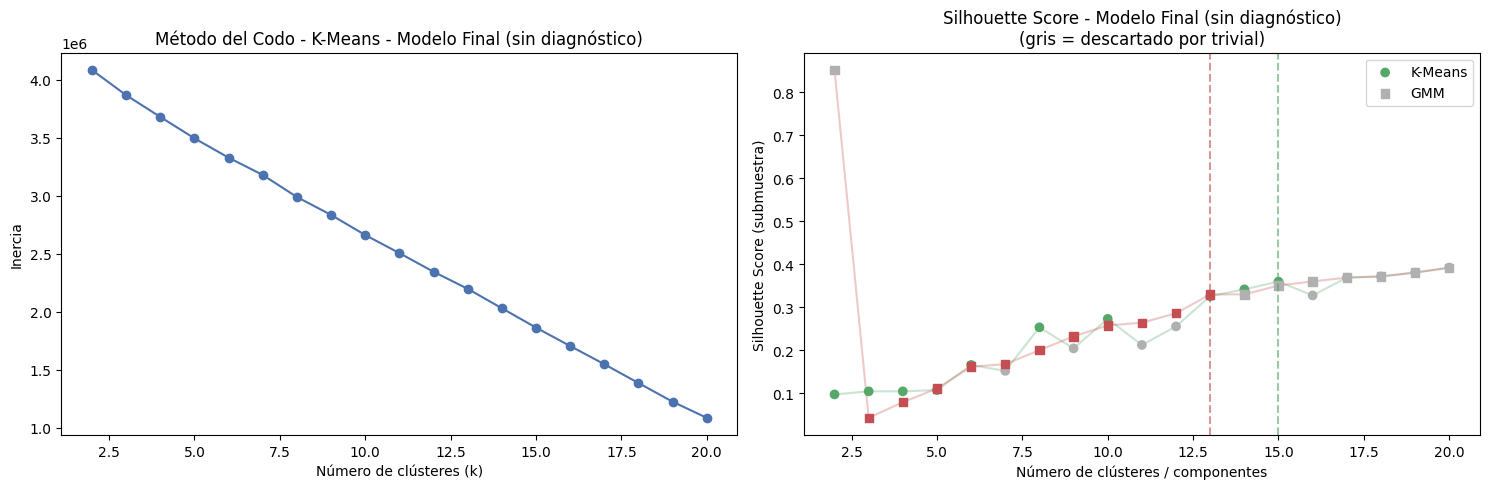

In [30]:
graficar_busqueda_k(resultado_final, RANGO_K_FINAL, titulo_sufijo='- Modelo Final (sin diagnóstico)')

### 12.4. Entrenamiento de los Modelos Finales

In [31]:
k_final_modelo = resultado_final['k_final']
n_final_modelo = resultado_final['n_final']

kmeans_final_modelo = resultado_final['modelos_km'][k_final_modelo]
df_uci['Cluster_KMeans_Final'] = kmeans_final_modelo.labels_

gmm_final_modelo = resultado_final['modelos_gmm'][n_final_modelo]
df_uci['Cluster_GMM_Final'] = resultado_final['etiquetas_gmm'][n_final_modelo]

print(f"K-Means final (Modelo Final) - k={k_final_modelo}:")
display(df_uci['Cluster_KMeans_Final'].value_counts().sort_index().rename('N pacientes').to_frame())

print(f"\nGMM final (Modelo Final) - n={n_final_modelo}:")
display(df_uci['Cluster_GMM_Final'].value_counts().sort_index().rename('N pacientes').to_frame())

K-Means final (Modelo Final) - k=15:


,N pacientes
Cluster_KMeans_Final,
0,21682
1,21814
2,5945
3,4007
4,20532
5,6029
6,1011
7,4363
8,53349



GMM final (Modelo Final) - n=13:


,N pacientes
Cluster_GMM_Final,
0,57678
1,4534
2,20472
3,21587
4,5959
5,21640
6,4186
7,1480
8,5908


### 12.5. Perfilado de Clústeres

In [32]:
perfil_kmeans_final = perfilar_clusters(df_uci, 'Cluster_KMeans_Final')
print("Perfil de clústeres - K-Means, Modelo Final:")
display(
    perfil_kmeans_final.style
        .background_gradient(cmap='Oranges', subset=[f'{c} (%)' for c in comorbilidades])
        .background_gradient(cmap='Blues', subset=['Edad media'])
)

Perfil de clústeres - K-Means, Modelo Final:


,N pacientes,% del total,Edad media,FC media (lpm),FR media (rpm),PAM media (mmHg),Temp. media (°C),Diabetes (%),Cirrhosis (%),HepaticFailure (%),MetastaticCancer (%),Leukemia (%),Immunosuppression (%),MI (%),Diagnóstico más frecuente,% ese diagnóstico,Servicio más frecuente,% ese servicio
Cluster,,,,,,,,,,,,,,,,,,
0,21682,13.380000,64.400000,105.800000,29.000000,86.200000,36.500000,20.800000,0.000000,0.000000,2.700000,0.800000,3.900000,0.400000,Emphysema/bronchitis,18.100000,pulmonary,100.000000
1,21814,13.460000,65.200000,110.800000,29.400000,76.400000,36.600000,24.800000,0.000000,0.000000,3.300000,1.600000,5.500000,0.500000,"Sepsis, pulmonary",36.200000,infectious diseases,99.700000
2,5945,3.670000,45.400000,108.800000,22.400000,83.400000,36.500000,71.100000,0.400000,0.200000,0.700000,0.200000,1.000000,0.300000,Diabetic ketoacidosis,76.700000,endocrine,100.000000
3,4007,2.470000,59.200000,98.400000,24.200000,82.400000,36.400000,21.500000,0.800000,0.500000,2.700000,0.800000,3.500000,0.700000,Other Diagnosis,56.500000,general,100.000000
4,20532,12.670000,62.400000,93.600000,23.700000,99.500000,36.500000,17.500000,0.000000,0.000000,2.600000,0.700000,2.200000,0.300000,"CVA, cerebrovascular accident/stroke",29.000000,neurologic,99.900000
5,6029,3.720000,43.100000,102.400000,24.500000,89.500000,36.500000,7.500000,1.000000,0.400000,0.200000,0.100000,0.500000,0.100000,"Overdose, sedatives, hypnotics, antipsychotics, benzodiazepines",23.400000,toxicology,100.000000
6,1011,0.620000,62.300000,103.400000,27.900000,80.300000,36.600000,19.600000,3.100000,2.700000,4.100000,3.400000,6.600000,0.700000,Anemia,59.100000,hematology,100.000000
7,4363,2.690000,64.100000,100.500000,22.000000,88.700000,36.500000,12.800000,0.600000,0.600000,10.000000,0.900000,7.400000,0.300000,Other Diagnosis,69.500000,oncology,67.400000
8,53349,32.930000,65.500000,94.100000,23.900000,87.700000,36.300000,23.900000,0.000000,0.000000,0.900000,0.600000,1.400000,1.900000,Other Diagnosis,21.800000,cardiovascular,87.200000


In [33]:
perfil_gmm_final = perfilar_clusters(df_uci, 'Cluster_GMM_Final')
print("Perfil de clústeres - GMM, Modelo Final:")
display(
    perfil_gmm_final.style
        .background_gradient(cmap='Oranges', subset=[f'{c} (%)' for c in comorbilidades])
        .background_gradient(cmap='Blues', subset=['Edad media'])
)

Perfil de clústeres - GMM, Modelo Final:


,N pacientes,% del total,Edad media,FC media (lpm),FR media (rpm),PAM media (mmHg),Temp. media (°C),Diabetes (%),Cirrhosis (%),HepaticFailure (%),MetastaticCancer (%),Leukemia (%),Immunosuppression (%),MI (%),Diagnóstico más frecuente,% ese diagnóstico,Servicio más frecuente,% ese servicio
Cluster,,,,,,,,,,,,,,,,,,
0,57678,35.600000,65.300000,94.800000,23.800000,87.700000,36.300000,22.800000,0.000000,0.000000,1.700000,0.600000,2.000000,0.000000,Other Diagnosis,25.900000,cardiovascular,78.900000
1,4534,2.800000,63.400000,98.900000,25.500000,84.100000,36.400000,29.300000,3.200000,2.200000,2.300000,0.900000,2.900000,0.000000,"Renal failure, acute",46.500000,renal,100.000000
2,20472,12.640000,62.300000,93.600000,23.700000,99.600000,36.500000,17.500000,0.000000,0.000000,2.600000,0.700000,2.200000,0.000000,"CVA, cerebrovascular accident/stroke",28.900000,neurologic,99.900000
3,21587,13.320000,64.400000,105.800000,29.000000,86.200000,36.500000,20.700000,0.000000,0.000000,2.700000,0.800000,3.900000,0.000000,Emphysema/bronchitis,18.200000,pulmonary,100.000000
4,5959,3.680000,43.000000,102.400000,24.500000,89.500000,36.500000,7.400000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"Overdose, sedatives, hypnotics, antipsychotics, benzodiazepines",23.500000,toxicology,100.000000
5,21640,13.360000,65.300000,110.700000,29.400000,76.400000,36.600000,24.700000,0.000000,0.000000,3.300000,1.500000,5.400000,0.000000,"Sepsis, pulmonary",36.300000,infectious diseases,100.000000
6,4186,2.580000,59.200000,103.500000,24.700000,77.000000,36.400000,26.000000,64.700000,59.000000,2.500000,1.000000,4.000000,0.000000,Other Diagnosis,34.800000,gastrointestinal,35.100000
7,1480,0.910000,67.100000,94.100000,24.100000,81.800000,36.400000,37.900000,1.600000,1.400000,1.400000,0.900000,2.000000,100.000000,"CABG alone, coronary artery bypass grafting",18.000000,cardiovascular,67.500000
8,5908,3.650000,45.400000,108.900000,22.400000,83.400000,36.500000,71.000000,0.500000,0.000000,0.600000,0.000000,1.000000,0.000000,Diabetic ketoacidosis,76.900000,endocrine,100.000000


### 12.6. Validación Post-Hoc: Mortalidad Real por Clúster

Tasa de mortalidad global: 9.14%

K-Means (Modelo Final):


,N pacientes,Tasa mortalidad (%),Diferencia vs. media global (p.p.)
Cluster_KMeans_Final,,,
0,21682,11.660000,2.520000
1,21814,15.360000,6.220000
2,5945,1.160000,-7.980000
3,4007,5.760000,-3.380000
4,20532,8.170000,-0.970000
5,6029,0.800000,-8.340000
6,1011,8.610000,-0.530000
7,4363,9.560000,0.420000
8,53349,8.420000,-0.720000



GMM (Modelo Final):


,N pacientes,Tasa mortalidad (%),Diferencia vs. media global (p.p.)
Cluster_GMM_Final,,,
0,57678,8.520000,-0.620000
1,4534,6.370000,-2.770000
2,20472,8.160000,-0.980000
3,21587,11.630000,2.490000
4,5959,0.760000,-8.380000
5,21640,15.360000,6.220000
6,4186,14.840000,5.700000
7,1480,9.050000,-0.090000
8,5908,1.150000,-7.990000



Rango de mortalidad - K-Means (Final): [0.80%, 16.94%]
Rango de mortalidad - GMM (Final):      [0.76%, 15.36%]


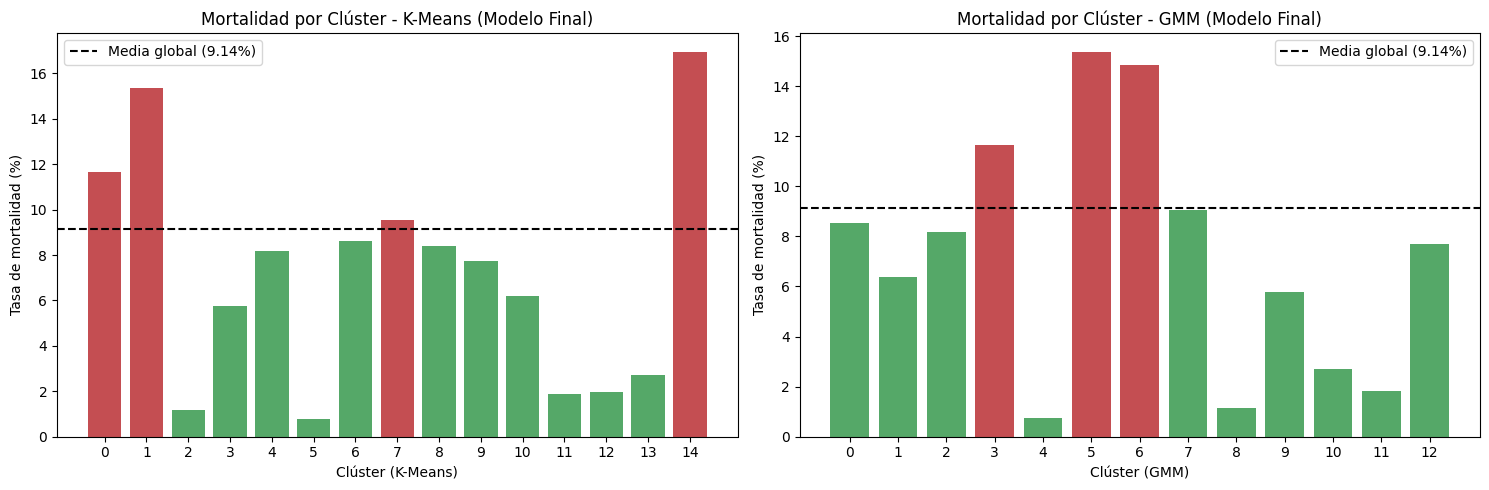

In [34]:
tabla_mortalidad_kmeans_final, _ = tasa_mortalidad_por_cluster(df_uci, 'Cluster_KMeans_Final')
tabla_mortalidad_gmm_final, _ = tasa_mortalidad_por_cluster(df_uci, 'Cluster_GMM_Final')

print(f"Tasa de mortalidad global: {tasa_global * 100:.2f}%\n")

print("K-Means (Modelo Final):")
display(tabla_mortalidad_kmeans_final.style.background_gradient(cmap='Reds', subset=['Tasa mortalidad (%)']))
print("\nGMM (Modelo Final):")
display(tabla_mortalidad_gmm_final.style.background_gradient(cmap='Reds', subset=['Tasa mortalidad (%)']))

print(f"\nRango de mortalidad - K-Means (Final): [{tabla_mortalidad_kmeans_final['Tasa mortalidad (%)'].min():.2f}%, {tabla_mortalidad_kmeans_final['Tasa mortalidad (%)'].max():.2f}%]")
print(f"Rango de mortalidad - GMM (Final):      [{tabla_mortalidad_gmm_final['Tasa mortalidad (%)'].min():.2f}%, {tabla_mortalidad_gmm_final['Tasa mortalidad (%)'].max():.2f}%]")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, tabla, nombre in [(axes[0], tabla_mortalidad_kmeans_final, 'K-Means'), (axes[1], tabla_mortalidad_gmm_final, 'GMM')]:
    colores = ['#C44E52' if v > 0 else '#55A868' for v in tabla['Diferencia vs. media global (p.p.)']]
    ax.bar(tabla.index.astype(str), tabla['Tasa mortalidad (%)'], color=colores)
    ax.axhline(tasa_global * 100, color='black', linestyle='--', label=f'Media global ({tasa_global * 100:.2f}%)')
    ax.set_xlabel(f'Clúster ({nombre})')
    ax.set_ylabel('Tasa de mortalidad (%)')
    ax.set_title(f'Mortalidad por Clúster - {nombre} (Modelo Final)')
    ax.legend()
plt.tight_layout()
plt.show()

### 12.7. Comparación K-Means vs. GMM (Modelo Final)

Adjusted Rand Index - K-Means vs. GMM (Modelo Final): 0.9101


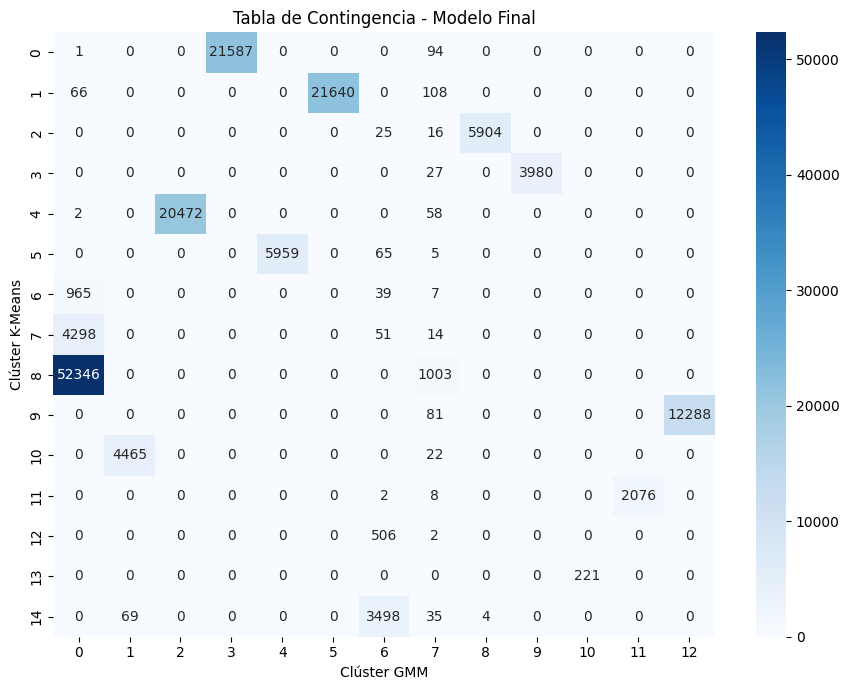

In [35]:
ari_final = adjusted_rand_score(df_uci['Cluster_KMeans_Final'], df_uci['Cluster_GMM_Final'])
print(f"Adjusted Rand Index - K-Means vs. GMM (Modelo Final): {ari_final:.4f}")

tabla_contingencia_final = pd.crosstab(df_uci['Cluster_KMeans_Final'], df_uci['Cluster_GMM_Final'])
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(tabla_contingencia_final, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Clúster GMM')
ax.set_ylabel('Clúster K-Means')
ax.set_title('Tabla de Contingencia - Modelo Final')
plt.tight_layout()
plt.show()

### 12.8. Visualización 2D (PCA)

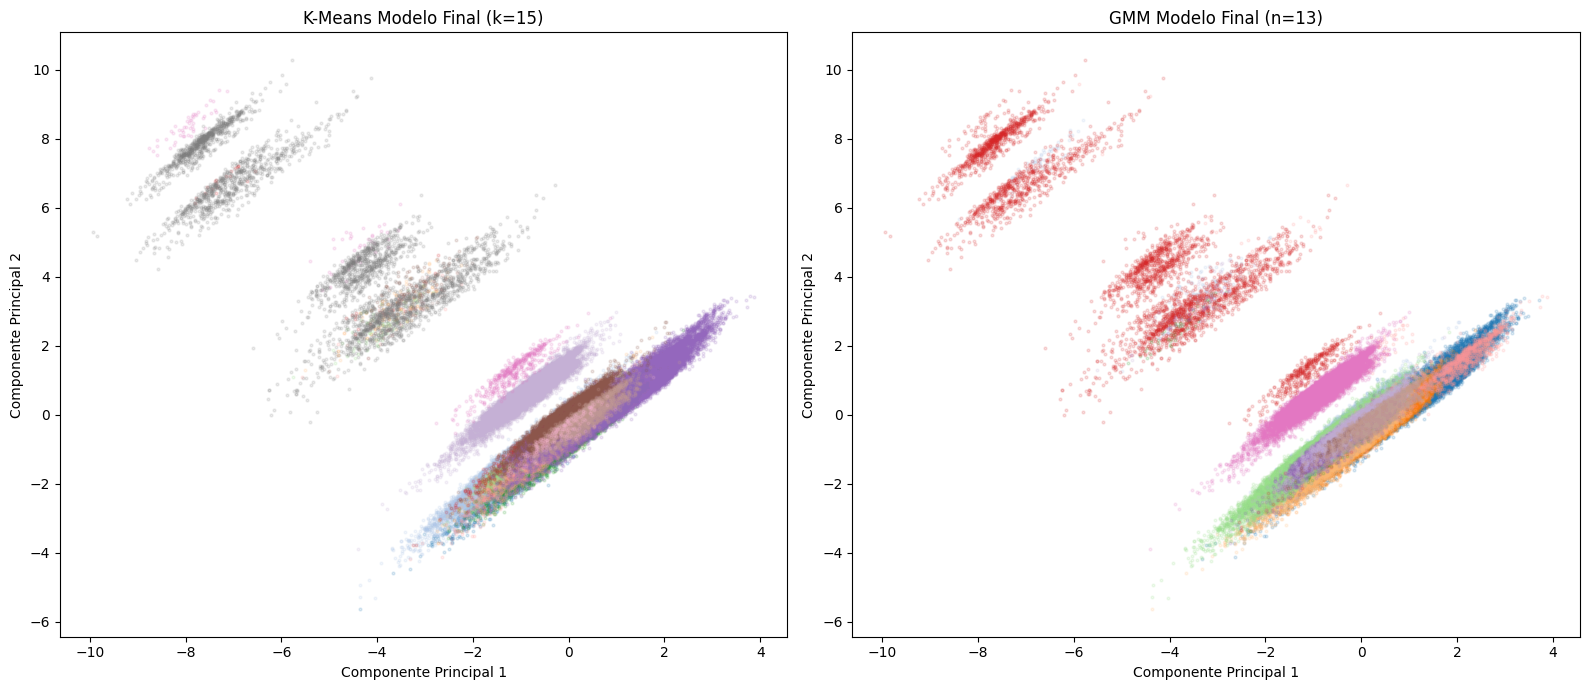

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

paleta_km_f = sns.color_palette('tab20', n_colors=df_uci['Cluster_KMeans_Final'].nunique())
for cid, color in zip(sorted(df_uci['Cluster_KMeans_Final'].unique()), paleta_km_f):
    mask = (df_uci['Cluster_KMeans_Final'] == cid).values
    axes[0].scatter(X_pca_final[mask, 0], X_pca_final[mask, 1], s=4, alpha=0.15, color=color)
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')
axes[0].set_title(f'K-Means Modelo Final (k={k_final_modelo})')

paleta_gmm_f = sns.color_palette('tab20', n_colors=df_uci['Cluster_GMM_Final'].nunique())
for cid, color in zip(sorted(df_uci['Cluster_GMM_Final'].unique()), paleta_gmm_f):
    mask = (df_uci['Cluster_GMM_Final'] == cid).values
    axes[1].scatter(X_pca_final[mask, 0], X_pca_final[mask, 1], s=4, alpha=0.15, color=color)
axes[1].set_xlabel('Componente Principal 1')
axes[1].set_ylabel('Componente Principal 2')
axes[1].set_title(f'GMM Modelo Final (n={n_final_modelo})')

plt.tight_layout()
plt.show()

## 13. Comparación Final: Modelo Inicial vs. Modelo Final

In [37]:
resumen_modelos = pd.DataFrame({
    'Modelo Inicial (con DiagnosisAdmission, k=2-10)': {
        'k K-Means': K_FINAL,
        'Silhouette K-Means': round(silhouette_kmeans[K_FINAL], 4),
        'n GMM': N_FINAL_GMM,
        'Silhouette GMM': round(silhouette_gmm[N_FINAL_GMM], 4),
        'ARI K-Means vs. GMM': round(ari, 4),
        'Mortalidad mín. (%)': min(tabla_mortalidad_kmeans['Tasa mortalidad (%)'].min(), tabla_mortalidad_gmm['Tasa mortalidad (%)'].min()),
        'Mortalidad máx. (%)': max(tabla_mortalidad_kmeans['Tasa mortalidad (%)'].max(), tabla_mortalidad_gmm['Tasa mortalidad (%)'].max()),
    },
    'Modelo Final (sin DiagnosisAdmission, k=2-20)': {
        'k K-Means': k_final_modelo,
        'Silhouette K-Means': round(resultado_final['candidatos_km'][k_final_modelo], 4),
        'n GMM': n_final_modelo,
        'Silhouette GMM': round(resultado_final['candidatos_gmm'][n_final_modelo], 4),
        'ARI K-Means vs. GMM': round(ari_final, 4),
        'Mortalidad mín. (%)': min(tabla_mortalidad_kmeans_final['Tasa mortalidad (%)'].min(), tabla_mortalidad_gmm_final['Tasa mortalidad (%)'].min()),
        'Mortalidad máx. (%)': max(tabla_mortalidad_kmeans_final['Tasa mortalidad (%)'].max(), tabla_mortalidad_gmm_final['Tasa mortalidad (%)'].max()),
    },
})
display(resumen_modelos)

ari_kmeans_inicial_vs_final = adjusted_rand_score(df_uci['Cluster_KMeans'], df_uci['Cluster_KMeans_Final'])
ari_gmm_inicial_vs_final = adjusted_rand_score(df_uci['Cluster_GMM'], df_uci['Cluster_GMM_Final'])

print("\n=== Adjusted Rand Index cruzado (Modelo Inicial vs. Modelo Final) ===")
print(f"K-Means Inicial vs. K-Means Final: {ari_kmeans_inicial_vs_final:.4f}")
print(f"GMM Inicial vs. GMM Final:         {ari_gmm_inicial_vs_final:.4f}")

,"Modelo Inicial (con DiagnosisAdmission, k=2-10)","Modelo Final (sin DiagnosisAdmission, k=2-20)"
k K-Means,9.0000,15.0000
Silhouette K-Means,0.0809,0.3599
n GMM,10.0000,13.0000
Silhouette GMM,0.0616,0.3301
ARI K-Means vs. GMM,0.5110,0.9101
Mortalidad mín. (%),0.0000,0.7600
Mortalidad máx. (%),21.4100,16.9400



=== Adjusted Rand Index cruzado (Modelo Inicial vs. Modelo Final) ===
K-Means Inicial vs. K-Means Final: 0.4376
GMM Inicial vs. GMM Final:         0.5020


### 13.1. Interpretación

El Modelo Final mejora al Inicial en las tres dimensiones que importan para una segmentación no supervisada fiable:

| | Modelo Inicial | Modelo Final |
|---|---|---|
| Silhouette máx. (K-Means / GMM) | 0.0809 / 0.0616 | **0.3599 / 0.3301** |
| Concordancia K-Means vs. GMM (ARI) | 0.5110 | **0.9101** |
| Rango de mortalidad por clúster | 0.00% - 21.41% | 0.76% - 16.94% |

El Silhouette se multiplica por ~4-5, y la concordancia entre algoritmos pasa de moderada a casi total, ambos son indicios de que el Modelo Final capta una estructura más real y más robusta al algoritmo concreto que se use. El rango de mortalidad es ligeramente menor en el extremo superior (16.94% frente a 21.41%), el Modelo Inicial, con k=9, todavía condensaba a los pacientes de mayor riesgo (parada respiratoria) en un clúster muy definido por diagnóstico; el Modelo Final identifica en su lugar un fenotipo de **fallo hepático/cirrosis** (~60-74% de prevalencia de esas comorbilidades) como el de mayor mortalidad, un hallazgo que no era visible como grupo propio en el Modelo Inicial, donde esas comorbilidades quedaban diluidas entre las 70 categorías de diagnóstico.

**El ARI cruzado entre Modelo Inicial y Modelo Final es moderado (K-Means: 0.4376; GMM: 0.5020)**, son dos particiones de tamaño distinto (9-10 clústeres frente a 15/13) construidas sobre espacios de variables distintos, no dos intentos de resolver el mismo problema con distinto resultado. El Modelo Final no es "el mismo clustering pero mejor afinado", es una segmentación distinta y más informativa.

### 13.2. Interpretación de los Componentes Principales (PC1/PC2)

Los gráficos 2D de las Secciones 9 y 12.8 proyectan a los pacientes sobre PC1 y PC2. Se recuperan los objetos `pca` (Modelo Inicial) y `pca_final` (Modelo Final) ya ajustados para ver qué variables originales pesan más en cada eje, y cuánta varianza real resume el propio gráfico 2D.

In [38]:
def mostrar_loadings_pca(pca_obj, feature_names, nombre_modelo, top_n=8):
    # Muestra la varianza explicada por PC1/PC2 y las variables con más peso en cada uno
    var_pc1 = pca_obj.explained_variance_ratio_[0] * 100
    var_pc2 = pca_obj.explained_variance_ratio_[1] * 100

    print(f"=== {nombre_modelo} ===")
    print(f"Varianza explicada por PC1: {var_pc1:.2f}%")
    print(f"Varianza explicada por PC2: {var_pc2:.2f}%")
    print(f"Varianza explicada por PC1+PC2 (lo que muestra el gráfico 2D): {var_pc1 + var_pc2:.2f}%")
    print(f"(de un total de {pca_obj.n_components_} componentes retenidos para el clustering)\n")

    for i, pc_nombre in enumerate(['PC1', 'PC2']):
        loadings = pd.Series(pca_obj.components_[i], index=feature_names).sort_values(key=abs, ascending=False)
        print(f"Top {top_n} variables con más peso en {pc_nombre}:")
        print(loadings.head(top_n).round(3).to_string())
        print()

    return var_pc1 + var_pc2


feature_names_inicial = comorbilidades + vitales_edad + list(encoder.get_feature_names_out(categoricas))
feature_names_final = comorbilidades + vitales_edad + list(encoder_final.get_feature_names_out(categoricas_final))

varianza_2d_inicial = mostrar_loadings_pca(pca, feature_names_inicial, 'Modelo Inicial (con DiagnosisAdmission)')
varianza_2d_final = mostrar_loadings_pca(pca_final, feature_names_final, 'Modelo Final (sin DiagnosisAdmission)')

print(f">>> El gráfico 2D del Modelo Final resume {varianza_2d_final:.2f}% de la varianza real, frente al "
      f"{varianza_2d_inicial:.2f}% del Modelo Inicial -- {varianza_2d_final / varianza_2d_inicial:.1f}x más "
      f"representativo, otra consecuencia de retirar la alta dimensionalidad de DiagnosisAdmission.")

=== Modelo Inicial (con DiagnosisAdmission) ===
Varianza explicada por PC1: 2.50%
Varianza explicada por PC2: 2.30%
Varianza explicada por PC1+PC2 (lo que muestra el gráfico 2D): 4.80%
(de un total de 75 componentes retenidos para el clustering)

Top 8 variables con más peso en PC1:
Service_cardiovascular                                                                                                   0.551
Service_infectious diseases                                                                                             -0.339
HeartRate_Admission                                                                                                     -0.241
DiagnosisAdmission_Sepsis, pulmonary                                                                                    -0.203
DiagnosisAdmission_Infarction, acute myocardial (MI)                                                                     0.194
DiagnosisAdmission_CHF, congestive heart failure                                 

**Lectura clínica de los ejes:**

- **Modelo Inicial:** PC1 enfrenta `Service_cardiovascular` (peso positivo) a `Service_infectious diseases` y una frecuencia cardiaca elevada (peso negativo), un eje aproximado sería "cardiovascular vs. séptico". PC2 enfrenta `Service_infectious diseases` y mayor edad (positivo) a `Service_toxicology`/`Service_neurologic` y cetoacidosis diabética (negativo), un eje "séptico/mayor edad vs. intoxicación/joven". Ambos ejes están dominados por combinaciones de `Service` y diagnósticos concretos.
- **Modelo Final:** tanto PC1 como PC2 quedan dominados por `HepaticFailure` y `Cirrhosis` (con distinto signo en cada uno, ya que estas dos comorbilidades están muy correlacionadas entre sí y concentran gran parte de la varianza tras estandarizar). Es coherente con el hallazgo ya documentado en la Sección 12.5, el fenotipo de fallo hepático es precisamente el rasgo diferencial más marcado de este modelo, y aquí se confirma que también domina la propia geometría del espacio de PCA, no solo el perfilado post-hoc.

## 14. Conclusiones Generales

Este cuaderno parte de un modelo inicial (k=9 K-Means / n=10 GMM, con `DiagnosisAdmission`, buscado en el rango 2-10) y dos dudas metodológicas razonables sobre él, si ese rango de búsqueda era suficiente, y si la variable de diagnóstico estaba distorsionando el clustering. Ambas dudas se investigaron con un conjunto de pruebas adicionales.

**Conclusión de las pruebas:** ampliar el rango de k manteniendo `DiagnosisAdmission` no converge, el óptimo sigue en el borde del rango probado incluso a k=30, y el acuerdo entre K-Means y GMM empeora cuantos más clústeres se piden (ARI 0.51 → 0.36). La mejora real vino de **retirar `DiagnosisAdmission`**, con esa única variable fuera, aparece un óptimo estable (k=15 / n=13, idéntico con rango 2-10, 2-20 o 2-30), con un Silhouette 4-5 veces mayor y una concordancia entre algoritmos casi total (ARI=0.9101).

**Modelo Final adoptado:** K-Means (k=15) y GMM (n=13), sin `DiagnosisAdmission`, sobre comorbilidades + vitales/edad + `Service`. La validación post-hoc confirma que los fenotipos encontrados tienen sentido clínico, un gradiente de mortalidad claro desde pacientes jóvenes con intoxicación/cetoacidosis diabética (<1%) hasta pacientes con fallo hepático/cirrosis (15-17%, el fenotipo de mayor riesgo en este modelo), reproducido de forma casi idéntica por dos algoritmos con lógicas de agrupación distintas.

## 15. Exportación para el dashboard: resultados de clustering (Modelo Final)

In [39]:
os.makedirs('../data', exist_ok=True)

cols_filtro = ['Age', 'Gender', 'Ethnicity', 'UnitType', 'Service']
cols_comorbilidades = ['Diabetes', 'Cirrhosis', 'HepaticFailure', 'MetastaticCancer',
                        'Leukemia', 'Immunosuppression', 'MI']
cols_vitales = ['HeartRate_Admission', 'RespiratoryRate_Admission', 'MeanBP_Admission', 'Temperature']
cols_resultado = ['DiedInHospital', 'Cluster_KMeans_Final', 'Cluster_GMM_Final']

df_export_clustering = df_uci[cols_filtro + cols_comorbilidades + cols_vitales + cols_resultado].copy()
df_export_clustering['PC1'] = X_pca_final[:, 0]
df_export_clustering['PC2'] = X_pca_final[:, 1]

df_export_clustering.to_parquet('../data/clustering_resultados.parquet', index=False)
print(f"Exportado data/clustering_resultados.parquet -- {df_export_clustering.shape}")

Exportado data/clustering_resultados.parquet -- (162009, 21)
